# 52 · Complex FFT: phase coherence & normalization

**Question: what is the best way to feed the *complex* FFT into the model?**

Probe: the three empty-box scenes of experiment-25 (outputs `000000`–`000002`), each recorded once per speaker (1–8). Same physical scene, recorded 3x per speaker — so any disagreement between the three recordings is *nuisance*, and anything reproducible is *signal*.

1. **Magnitude sanity** — |X| should overlap across recordings, differ across speakers
2. **Phase coherence (go/no-go)** — is absolute phase reproducible, or trigger-jitter noise?
3. **Phase referencing** — rotate by the array-mean phase; does phase become comparable across samples?
4. **Signal modes** — what `magnitude` / `complex` / `mag_phase` each hand the model
5. **Normalization** — `std-sample` vs `z-sample` on complex data: rescale without distorting phase?
6. **Empty-diff** — is subtracting the empty-box mean valid in the complex domain?

In [1]:
import sys
from pathlib import Path

def _find_repo_root(marker='pyproject.toml'):
    for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (candidate / marker).exists(): return candidate
    raise RuntimeError('repo root not found')

REPO_ROOT = _find_repo_root()
SRC_DIR = REPO_ROOT / 'src'
for p in (REPO_ROOT, SRC_DIR):
    if str(p) not in sys.path: sys.path.insert(0, str(p))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils.io_utils import load
from data.post_process import extract_signal, normalize_fft

SAMPLES_DIR = Path(r'D:\eturok\experiment-25\samples')
OUTPUTS, SPEAKERS, PAIRS = [0, 1, 2], list(range(1, 9)), [(0, 1), (0, 2), (1, 2)]

# fixed colors everywhere: outputs (and output-pairs) keep the same hue in every figure; speakers are viridis-ordered
OUT_COLORS = {0: '#0072B2', 1: '#E69F00', 2: '#009E73'}
PAIR_COLORS = {(0, 1): '#0072B2', (0, 2): '#E69F00', (1, 2): '#009E73'}
SPK_COLORS = {spk: plt.cm.viridis(t) for spk, t in zip(SPEAKERS, np.linspace(0.05, 0.9, len(SPEAKERS)))}
RAW_GRAY, REF_BLUE = '#9ca3af', '#0072B2'
plt.rcParams.update({'figure.dpi': 80, 'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.25})

In [2]:
# 24 empty-box samples: outputs 000000-000002 x speakers 1-8; sample dir index = output*8 + (speaker-1)
# samples whose vibration pipeline hasn't run yet (no 03_fft.npz) are skipped
ffts, meta, missing = {}, [], []
for out in OUTPUTS:
    for spk in SPEAKERS:
        sample_dir = SAMPLES_DIR / f'{out * 8 + (spk - 1):06d}'
        fft_path = sample_dir / 'vibration/03_fft.npz'
        if not fft_path.exists():
            missing.append(sample_dir.name); continue
        npz = load(fft_path)
        ffts[(out, spk)] = npz['fft'][0]  # (lasers, freqs, x/y), complex64
        meta.append(dict(sample_id=sample_dir.name, output=out, speaker=spk))
freqs = npz['freqs']
L, F, C = ffts[(0, 1)].shape

def avail(spk): return [out for out in OUTPUTS if (out, spk) in ffts]
def avail_pairs(spk): return [(o1, o2) for o1, o2 in PAIRS if (o1, spk) in ffts and (o2, spk) in ffts]

if missing: print(f'missing vibration/03_fft.npz (skipped): {missing}')
print(f'{len(ffts)} samples | lasers={L} freqs={F} ({freqs[0]:.0f}-{freqs[-1]:.0f} Hz) channels={C} | {sum(v.nbytes for v in ffts.values()) / 1e6:.0f} MB')
pd.DataFrame(meta).groupby('output').agg(samples=('sample_id', 'count'), speakers=('speaker', list))

24 samples | lasers=100 freqs=2946 (50-1000 Hz) channels=2 | 113 MB


,samples,speakers
output,,
0,8,"[1, 2, 3, 4, 5, 6, 7, 8]"
1,8,"[1, 2, 3, 4, 5, 6, 7, 8]"
2,8,"[1, 2, 3, 4, 5, 6, 7, 8]"


## 1 · Magnitude sanity check

Same scene, three recordings: the magnitude spectra should overlap almost perfectly within a speaker and differ across speakers (loudness, spectral shape). If this fails, something upstream is broken and no phase question matters yet.

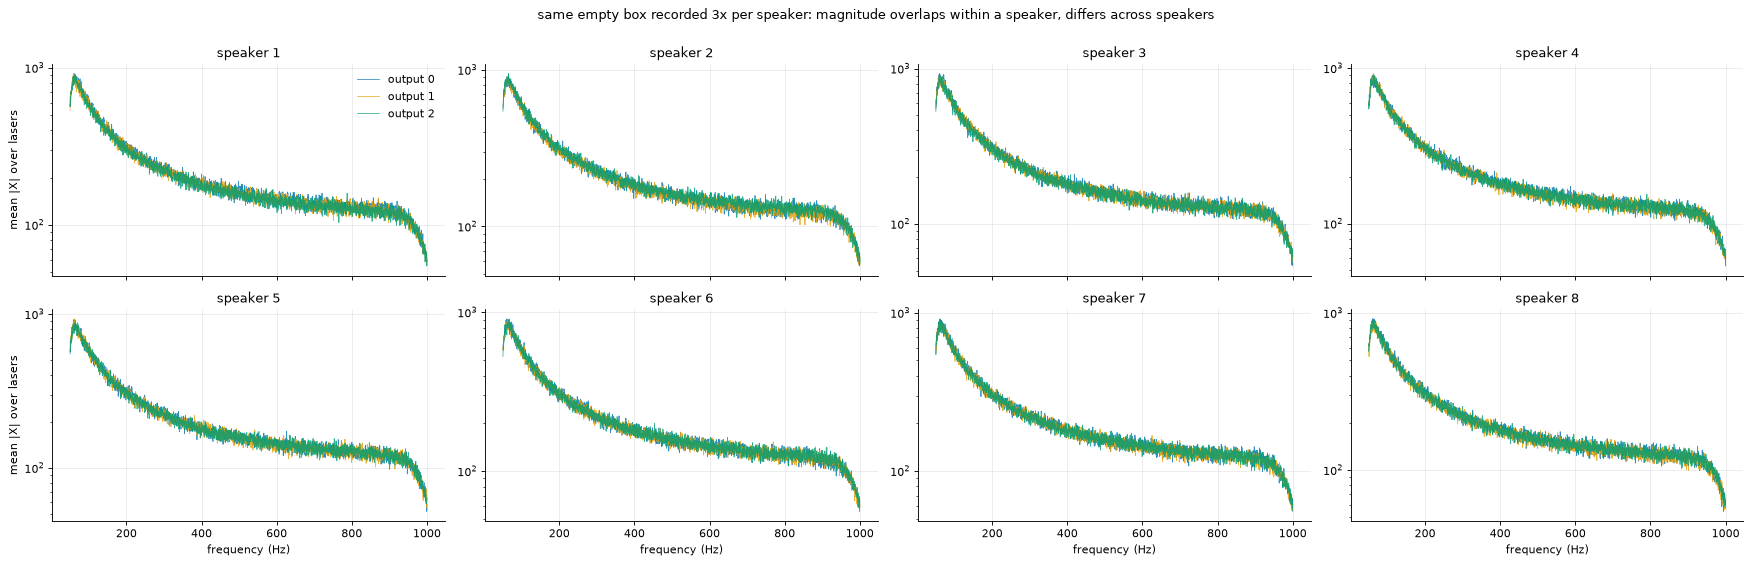

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(22, 7), sharex=True)
for spk, ax in zip(SPEAKERS, axes.flat):
    for out in avail(spk):
        ax.semilogy(freqs, np.abs(ffts[(out, spk)]).mean(axis=(0, 2)), lw=0.7, color=OUT_COLORS[out], alpha=0.8, label=f'output {out}')
    ax.set_title(f'speaker {spk}')
for ax in axes[1]: ax.set_xlabel('frequency (Hz)')
for ax in axes[:, 0]: ax.set_ylabel('mean |X| over lasers')
axes[0, 0].legend(frameon=False)
fig.suptitle('same empty box recorded 3x per speaker: magnitude overlaps within a speaker, differs across speakers', y=1.0)
fig.tight_layout()
plt.show()

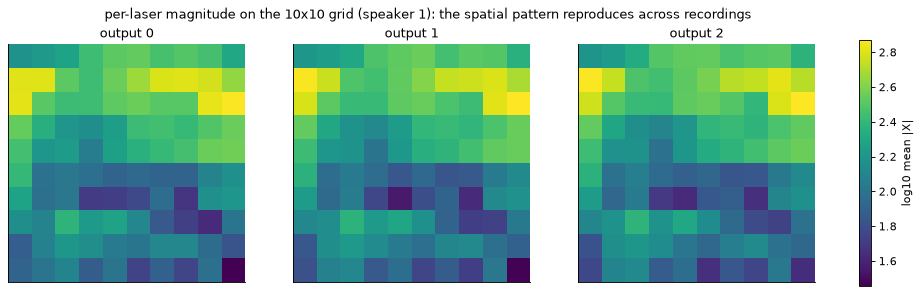

In [4]:
spk = 1
vals = [np.log10(np.abs(ffts[(out, spk)]).mean(axis=(1, 2))).reshape(10, 10) for out in avail(spk)]
vmin, vmax = min(v.min() for v in vals), max(v.max() for v in vals)
fig, axes = plt.subplots(1, len(vals), figsize=(14, 4))
for out, v, ax in zip(avail(spk), vals, axes):
    im = ax.imshow(v, cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_title(f'output {out}'); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
fig.colorbar(im, ax=axes, fraction=0.02, label='log10 mean |X|')
fig.suptitle(f'per-laser magnitude on the 10x10 grid (speaker {spk}): the spatial pattern reproduces across recordings')
plt.show()

## 2 · Phase coherence across recordings — the go/no-go

For two recordings $X_1, X_2$ of the same scene, the cross-spectrum phase $\angle(X_1 \cdot \overline{X_2})$ cancels the scene and leaves only the recording-to-recording phase difference:

- **flat at 0** → captures are phase-locked; raw complex features are already comparable across samples
- **straight ramp** → a constant time offset $t_0$ between captures (slope $= -2\pi t_0$)
- **random scatter** → trigger jitter; absolute phase is pure noise

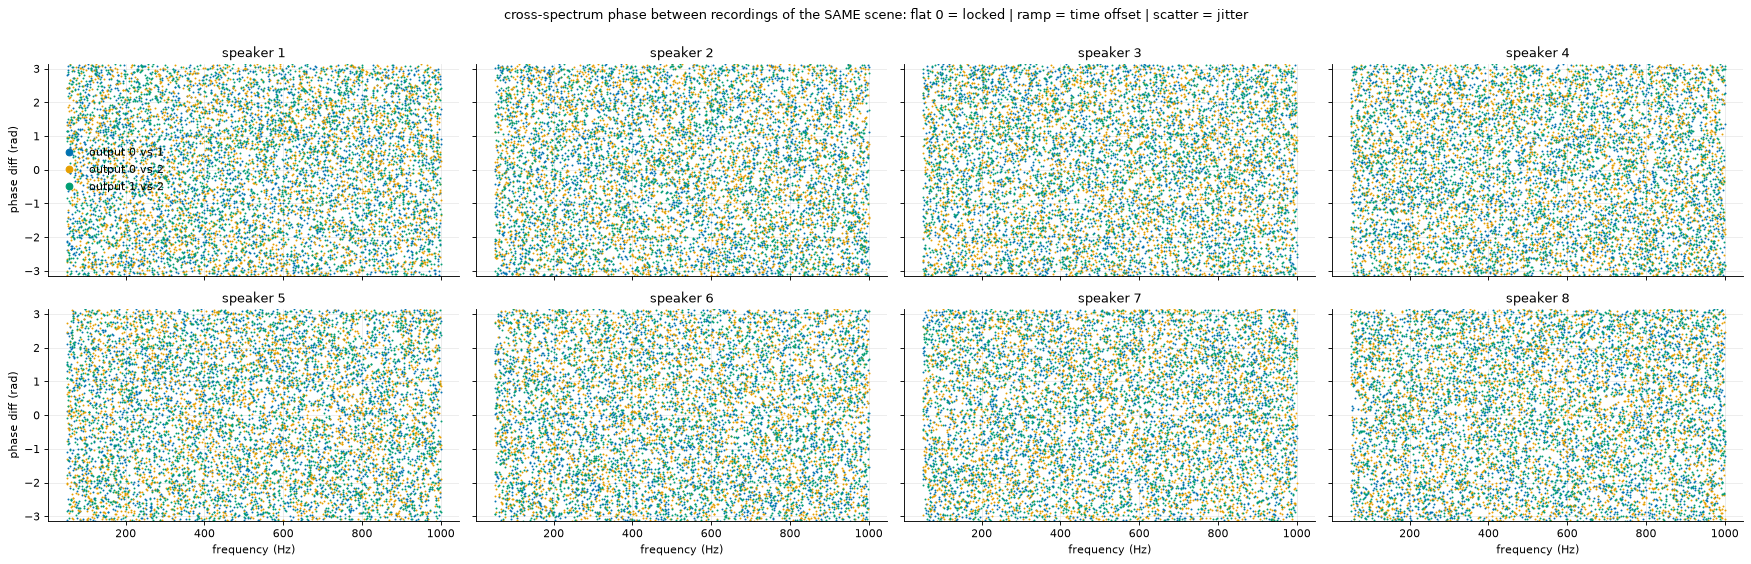

In [5]:
def cross_phase(a, b):  # per-frequency phase of the laser/channel-averaged cross-spectrum -> (F,)
    return np.angle((a * np.conj(b)).mean(axis=(0, 2)))

fig, axes = plt.subplots(2, 4, figsize=(22, 7), sharex=True, sharey=True)
for spk, ax in zip(SPEAKERS, axes.flat):
    for o1, o2 in avail_pairs(spk):
        ax.plot(freqs, cross_phase(ffts[(o1, spk)], ffts[(o2, spk)]), '.', ms=1.5, color=PAIR_COLORS[(o1, o2)], label=f'output {o1} vs {o2}')
    ax.set_title(f'speaker {spk}'); ax.set_ylim(-np.pi, np.pi)
for ax in axes[1]: ax.set_xlabel('frequency (Hz)')
for ax in axes[:, 0]: ax.set_ylabel('phase diff (rad)')
axes[0, 0].legend(frameon=False, markerscale=8)
fig.suptitle('cross-spectrum phase between recordings of the SAME scene: flat 0 = locked | ramp = time offset | scatter = jitter', y=1.0)
fig.tight_layout()
plt.show()

In [6]:
def coherence(a, b):
    # amplitude-weighted phase alignment of the cross-spectrum: |sum X1*conj(X2)| / sum |X1*conj(X2)|
    # 1 = phases agree at every (laser, freq, channel), ~0 = random
    x = a.astype(np.complex128) * np.conj(b.astype(np.complex128))
    return float(np.abs(x.sum()) / max(np.abs(x).sum(), 1e-12))

coh_raw = pd.DataFrame([dict(speaker=spk, pair=f'{o1}-{o2}', coherence=coherence(ffts[(o1, spk)], ffts[(o2, spk)])) for spk in SPEAKERS for o1, o2 in avail_pairs(spk)])
coh_raw.pivot(index='speaker', columns='pair', values='coherence').round(3)

pair,0-1,0-2,1-2
speaker,,,
1,0.002,0.013,0.018
2,0.010,0.005,0.001
3,0.015,0.006,0.008
4,0.008,0.010,0.009
5,0.003,0.006,0.001
6,0.002,0.006,0.007
7,0.011,0.008,0.016
8,0.006,0.010,0.008


## 3 · Phase referencing

Rotate every (frequency, channel) by the phase of the laser-mean: $x \cdot e^{-i\,\angle(\mathrm{mean}_{\mathrm{lasers}}\,x)}$.

Any *global* per-recording phase (trigger offset, stimulus phase) cancels exactly, because it multiplies every laser identically. What survives is the **relative phase between lasers** — the spatial propagation structure, which is the geometric information phase should contribute. If referencing works, the coherence numbers from section 2 should jump toward 1.

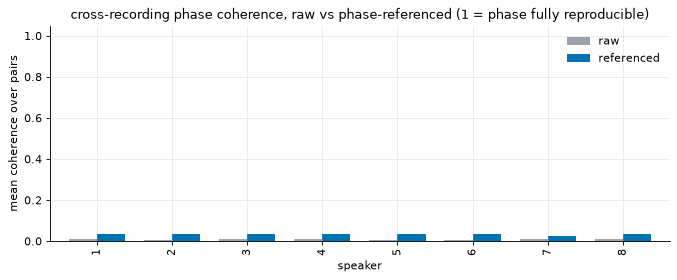

,raw,referenced
speaker,,
1,0.011,0.034
2,0.006,0.034
3,0.010,0.034
4,0.009,0.035
5,0.003,0.034
6,0.005,0.034
7,0.012,0.027
8,0.008,0.035


In [7]:
def phase_reference(x):
    # rotate each (freq, channel) by the phase of the laser-mean: cancels any global per-recording
    # phase; the relative phase between lasers -- the spatial signal -- survives
    ref = x.mean(axis=0, keepdims=True)  # (1, F, C)
    return x * np.exp(-1j * np.angle(ref))

ffts_ref = {k: phase_reference(v) for k, v in ffts.items()}
coh_ref = pd.DataFrame([dict(speaker=spk, pair=f'{o1}-{o2}', coherence=coherence(ffts_ref[(o1, spk)], ffts_ref[(o2, spk)])) for spk in SPEAKERS for o1, o2 in avail_pairs(spk)])

per_spk = pd.DataFrame({'raw': coh_raw.groupby('speaker').coherence.mean(), 'referenced': coh_ref.groupby('speaker').coherence.mean()})
ax = per_spk.plot.bar(figsize=(10, 3.5), color=[RAW_GRAY, REF_BLUE], width=0.75)
ax.set_ylabel('mean coherence over pairs'); ax.set_ylim(0, 1.05); ax.legend(frameon=False)
ax.set_title('cross-recording phase coherence, raw vs phase-referenced (1 = phase fully reproducible)')
plt.show()
per_spk.round(3)

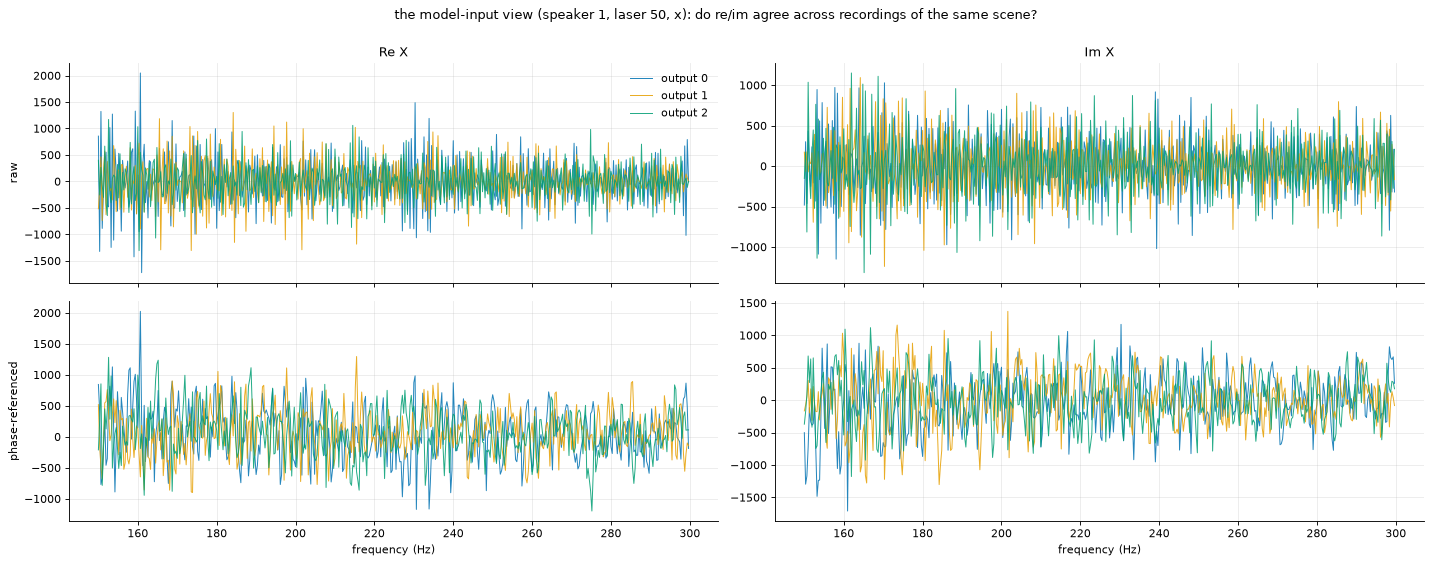

In [8]:
spk, laser, ch = 1, 50, 0
band = slice(*np.searchsorted(freqs, [150, 300]))
fig, axes = plt.subplots(2, 2, figsize=(18, 7), sharex=True)
for row, (data, name) in enumerate([(ffts, 'raw'), (ffts_ref, 'phase-referenced')]):
    for out in OUTPUTS:
        axes[row, 0].plot(freqs[band], data[(out, spk)][laser, band, ch].real, lw=0.9, color=OUT_COLORS[out], alpha=0.85, label=f'output {out}')
        axes[row, 1].plot(freqs[band], data[(out, spk)][laser, band, ch].imag, lw=0.9, color=OUT_COLORS[out], alpha=0.85)
    axes[row, 0].set_ylabel(name)
axes[0, 0].set_title('Re X'); axes[0, 1].set_title('Im X')
for ax in axes[1]: ax.set_xlabel('frequency (Hz)')
axes[0, 0].legend(frameon=False)
fig.suptitle(f'the model-input view (speaker {spk}, laser {laser}, x): do re/im agree across recordings of the same scene?', y=1.0)
fig.tight_layout()
plt.show()

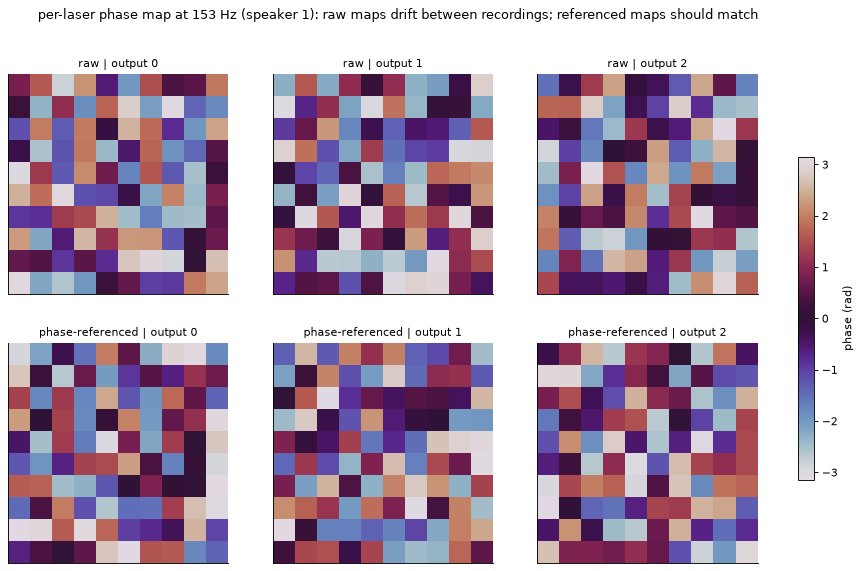

In [9]:
spk, ch = 1, 0
f0 = band.start + int(np.argmax(np.abs(ffts[(0, spk)][:, band, ch]).mean(axis=0)))
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for row, (data, name) in enumerate([(ffts, 'raw'), (ffts_ref, 'phase-referenced')]):
    for out, ax in zip(OUTPUTS, axes[row]):
        im = ax.imshow(np.angle(data[(out, spk)][:, f0, ch]).reshape(10, 10), cmap='twilight', vmin=-np.pi, vmax=np.pi)
        ax.set_title(f'{name} | output {out}', fontsize=10); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
fig.colorbar(im, ax=axes, fraction=0.02, label='phase (rad)')
fig.suptitle(f'per-laser phase map at {freqs[f0]:.0f} Hz (speaker {spk}): raw maps drift between recordings; referenced maps should match')
plt.show()

## 4 · What each signal mode hands the model

- `magnitude` — phase-blind, but hands the model phase-invariance for free
- `complex` — `[re, im]` channels: smooth and complete, but only comparable across samples if phase is coherent (or referenced)
- `mag_phase` — uses raw `angle`, which **wraps at ±π**: two nearly identical signals can differ by 2π, poison for a linear embed

magnitude  -> X.shape (1, 100, 2946, 2)   channels: [|x|, |y|]
complex    -> X.shape (1, 100, 2946, 4)   channels: [re_x, re_y, im_x, im_y]
mag_phase  -> X.shape (1, 100, 2946, 4)   channels: [|x|, |y|, ang_x, ang_y]


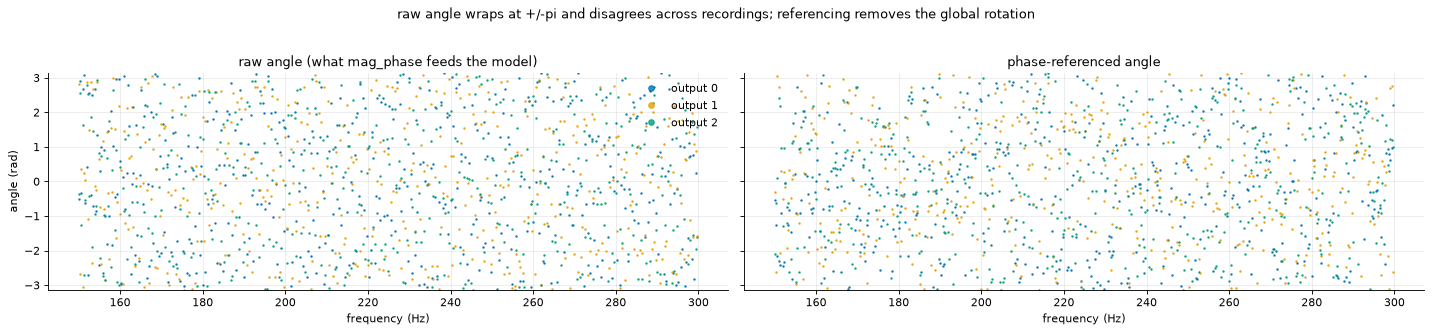

In [10]:
x = ffts[(0, 1)][None]
for mode in ['magnitude', 'complex', 'mag_phase']:
    channels = {'magnitude': '[|x|, |y|]', 'complex': '[re_x, re_y, im_x, im_y]', 'mag_phase': '[|x|, |y|, ang_x, ang_y]'}[mode]
    print(f'{mode:10s} -> X.shape {extract_signal(x, mode).shape}   channels: {channels}')

spk, laser, ch = 1, 50, 0
fig, axes = plt.subplots(1, 2, figsize=(18, 4), sharey=True)
for ax, (data, name) in zip(axes, [(ffts, 'raw angle (what mag_phase feeds the model)'), (ffts_ref, 'phase-referenced angle')]):
    for out in OUTPUTS:
        ax.plot(freqs[band], np.angle(data[(out, spk)][laser, band, ch]), '.', ms=2.5, color=OUT_COLORS[out], alpha=0.8, label=f'output {out}')
    ax.set_title(name); ax.set_xlabel('frequency (Hz)'); ax.set_ylim(-np.pi, np.pi)
axes[0].set_ylabel('angle (rad)'); axes[0].legend(frameon=False, markerscale=4)
fig.suptitle('raw angle wraps at +/-pi and disagrees across recordings; referencing removes the global rotation', y=1.03)
fig.tight_layout()
plt.show()

## 5 · Normalization on complex data

Why normalize at all: speakers differ in overall scale by orders of magnitude. Per-sample **std** (`std-sample`) divides the whole sample by one positive scalar — the complex plane is rescaled uniformly, **angles untouched**. **`z-sample`** additionally subtracts the scalar mean of all `[re, im]` values; for FFT data that mean is near 0, so below we *quantify* how much phase it actually distorts instead of assuming.

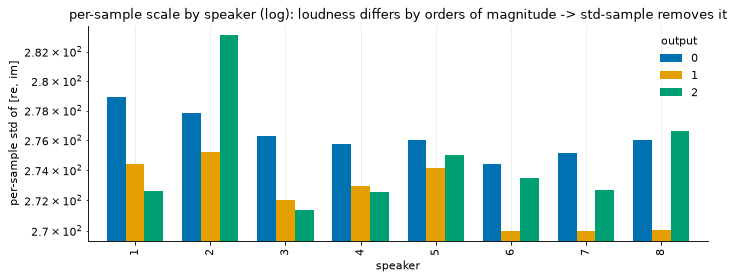

In [11]:
stds = pd.DataFrame([dict(output=out, speaker=spk, std=float(np.concatenate([v.real, v.imag], axis=-1).std())) for (out, spk), v in ffts.items()])
ax = stds.pivot(index='speaker', columns='output', values='std').plot.bar(figsize=(10, 3.5), logy=True, color=[OUT_COLORS[o] for o in OUTPUTS], width=0.75)
ax.set_ylabel('per-sample std of [re, im]'); ax.legend(title='output', frameon=False)
ax.set_title('per-sample scale by speaker (log): loudness differs by orders of magnitude -> std-sample removes it')
plt.show()

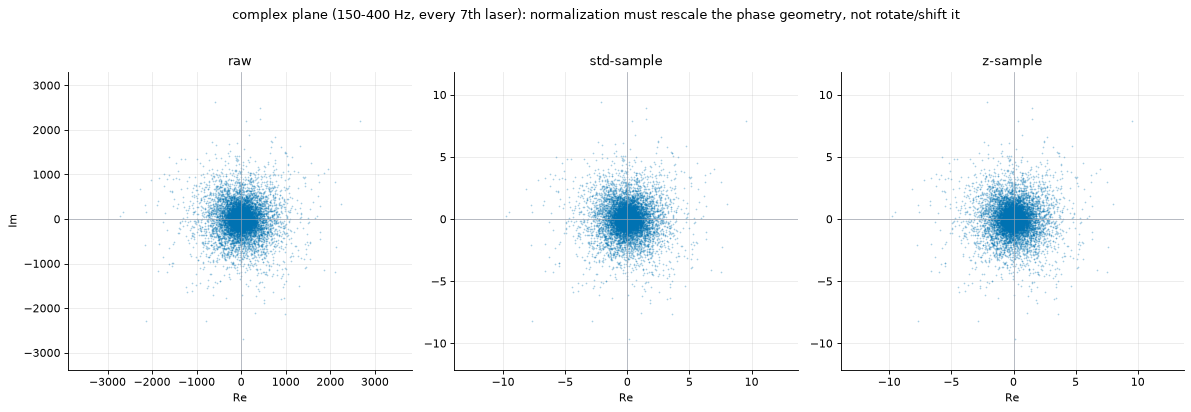

std-sample  max |angle change| = 5.687e-08 rad   (scalar mean it would subtract: 1.838e-03)
z-sample    max |angle change| = 1.692e-02 rad   (scalar mean it would subtract: 1.838e-03)


In [12]:
def as_complex(v): return v[..., :C] + 1j * v[..., C:]  # 'complex'-mode channels are [re_x, re_y, im_x, im_y]

spk, out = 1, 0
raw = extract_signal(ffts[(out, spk)][None], 'complex').astype(np.float32)
normed = {'std-sample': normalize_fft(raw, 'std-sample'), 'z-sample': normalize_fft(raw, 'z-sample')}

wide = slice(*np.searchsorted(freqs, [150, 400]))
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, v) in zip(axes, [('raw', raw)] + list(normed.items())):
    zz = as_complex(v[0])[::7, wide, 0].ravel()
    ax.plot(zz.real, zz.imag, '.', ms=1, color=REF_BLUE, alpha=0.35)
    ax.axhline(0, color=RAW_GRAY, lw=0.6); ax.axvline(0, color=RAW_GRAY, lw=0.6)
    ax.set_title(name); ax.set_xlabel('Re'); ax.set_aspect('equal', adjustable='datalim')
axes[0].set_ylabel('Im')
fig.suptitle('complex plane (150-400 Hz, every 7th laser): normalization must rescale the phase geometry, not rotate/shift it', y=1.02)
fig.tight_layout()
plt.show()

for name, v in normed.items():
    dang = np.angle(as_complex(v[0].astype(np.float64)) * np.conj(as_complex(raw[0].astype(np.float64))))
    print(f'{name:11s} max |angle change| = {np.abs(dang).max():.3e} rad   (scalar mean it would subtract: {raw.mean():.3e})')

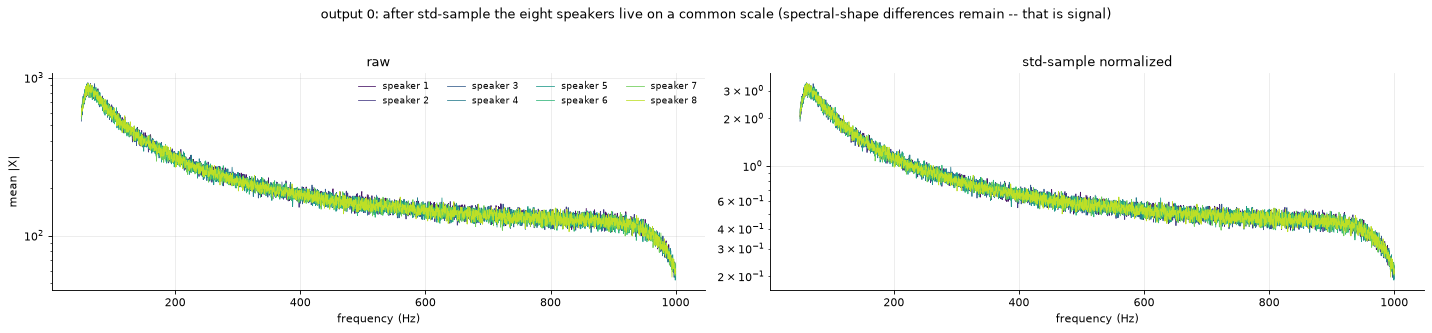

In [13]:
out = 0
fig, axes = plt.subplots(1, 2, figsize=(18, 4), sharex=True)
for spk in SPEAKERS:
    v = extract_signal(ffts[(out, spk)][None], 'complex').astype(np.float32)
    axes[0].semilogy(freqs, np.abs(as_complex(v[0])).mean(axis=(0, 2)), lw=0.7, color=SPK_COLORS[spk], label=f'speaker {spk}')
    axes[1].semilogy(freqs, np.abs(as_complex(normalize_fft(v, 'std-sample')[0])).mean(axis=(0, 2)), lw=0.7, color=SPK_COLORS[spk])
axes[0].set_title('raw'); axes[1].set_title('std-sample normalized')
axes[0].set_ylabel('mean |X|'); axes[0].legend(frameon=False, ncol=4, fontsize=8)
for ax in axes: ax.set_xlabel('frequency (Hz)')
fig.suptitle(f'output {out}: after std-sample the eight speakers live on a common scale (spectral-shape differences remain -- that is signal)', y=1.03)
fig.tight_layout()
plt.show()

## 6 · Is empty-diff valid in the complex domain?

Vibration superposes linearly in the *complex* field: $X_{\mathrm{object}} \approx X_{\mathrm{empty}} + X_{\mathrm{scattered}}$ — so subtracting the **complex** empty-box mean is physically principled (subtracting magnitudes is only a heuristic). But it only works if repeated empties average *coherently*. Metric: $|\mathrm{mean}\,X| \,/\, \mathrm{mean}\,|X|$ per (laser, freq, channel), averaged — **1 = coherent**, and for 3 recordings the fully-incoherent baseline is $1/\sqrt{3} \approx 0.58$.

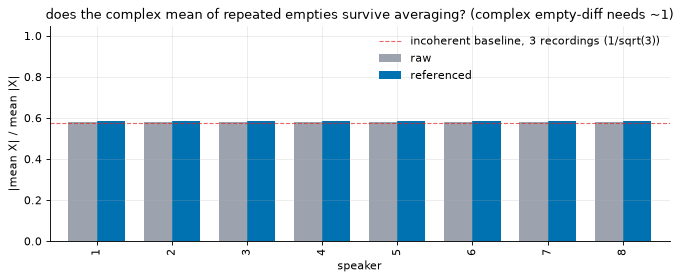

,n_recs,raw,referenced
speaker,,,
1,3,0.582,0.586
2,3,0.582,0.586
3,3,0.581,0.585
4,3,0.581,0.585
5,3,0.580,0.585
6,3,0.581,0.585
7,3,0.581,0.585
8,3,0.580,0.585


In [14]:
def mean_survival(stack):  # (N,L,F,C) complex -> mean over (L,F,C) of |mean_N X| / mean_N |X|
    stack = stack.astype(np.complex128)
    return float((np.abs(stack.mean(axis=0)) / np.maximum(np.abs(stack).mean(axis=0), 1e-12)).mean())

surv = pd.DataFrame([dict(speaker=spk, n_recs=len(avail(spk)),
                          raw=mean_survival(np.stack([ffts[(out, spk)] for out in avail(spk)])),
                          referenced=mean_survival(np.stack([ffts_ref[(out, spk)] for out in avail(spk)])))
                     for spk in SPEAKERS if len(avail(spk)) >= 2]).set_index('speaker')
ax = surv[['raw', 'referenced']].plot.bar(figsize=(10, 3.5), color=[RAW_GRAY, REF_BLUE], width=0.75)
for n in sorted(surv.n_recs.unique()):
    ax.axhline(1 / np.sqrt(n), color='#dc2626', lw=1, ls='--', alpha=0.7, label=f'incoherent baseline, {n} recordings (1/sqrt({n}))')
ax.set_ylabel('|mean X| / mean |X|'); ax.set_ylim(0, 1.05); ax.legend(frameon=False)
ax.set_title('does the complex mean of repeated empties survive averaging? (complex empty-diff needs ~1)')
plt.show()
surv.round(3)

## 7 · Rung 2: is the per-laser offset frequency-constant?

Section 3 referenced per *frequency* (one angle per frequency, shared by all lasers — "rung 3") and failed, which proves the nuisance is per-laser. The remaining hope ("rung 2") assumes each laser draws **one** random offset per capture, constant across frequency — then rotating each laser by one angle of its own cancels the speckle *and preserves all cross-frequency phase structure within the laser*.

Diagnostic: the cross-recording phase difference $\Delta\phi_l(f) = \angle(X_{1,l}(f)\cdot\overline{X_{2,l}(f)})$, per laser:

- **horizontal stripes** in the (laser × frequency) map / **flat lines** per laser → offset is frequency-constant → rung 2 recovers cross-frequency phase
- **noise in both directions** → the corruption is frequency-dependent → phase is unusable at any referencing granularity

Metrics: per-laser concentration $R_l = |\sum_f w\, e^{i\Delta\phi}| / \sum_f w$ (amplitude-weighted; 1 = constant offset, ~1/√F = random), and the **rung-2 ceiling**: cross-recording coherence after rotating every laser *optimally* — an upper bound no per-laser scheme can beat.

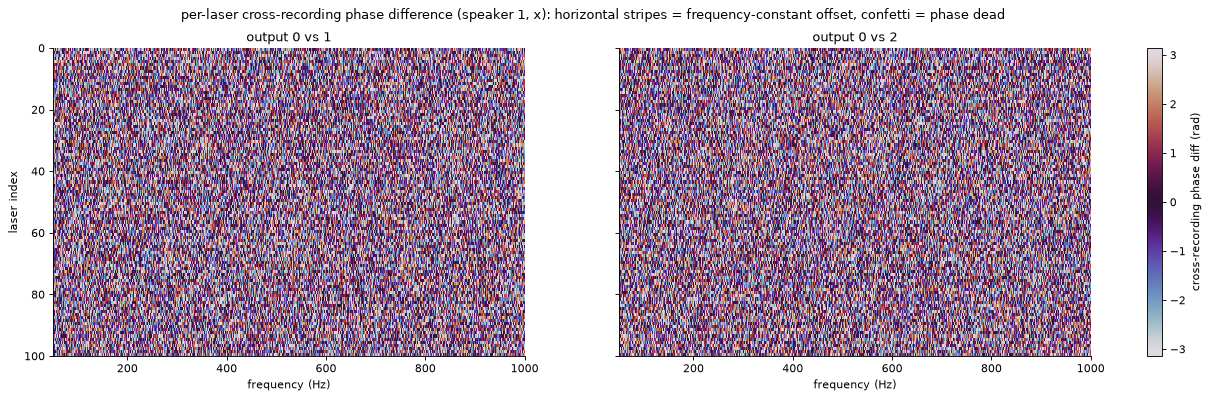

In [15]:
spk, ch = 1, 0
fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharey=True)
for ax, (o1, o2) in zip(axes, [(0, 1), (0, 2)]):
    dphi = np.angle(ffts[(o1, spk)][:, :, ch] * np.conj(ffts[(o2, spk)][:, :, ch]))  # (L, F)
    im = ax.imshow(dphi, cmap='twilight', vmin=-np.pi, vmax=np.pi, aspect='auto', extent=[freqs[0], freqs[-1], L, 0], interpolation='nearest')
    ax.set_title(f'output {o1} vs {o2}'); ax.set_xlabel('frequency (Hz)'); ax.grid(False)
axes[0].set_ylabel('laser index')
fig.colorbar(im, ax=axes, fraction=0.02, label='cross-recording phase diff (rad)')
fig.suptitle(f'per-laser cross-recording phase difference (speaker {spk}, x): horizontal stripes = frequency-constant offset, confetti = phase dead')
plt.show()

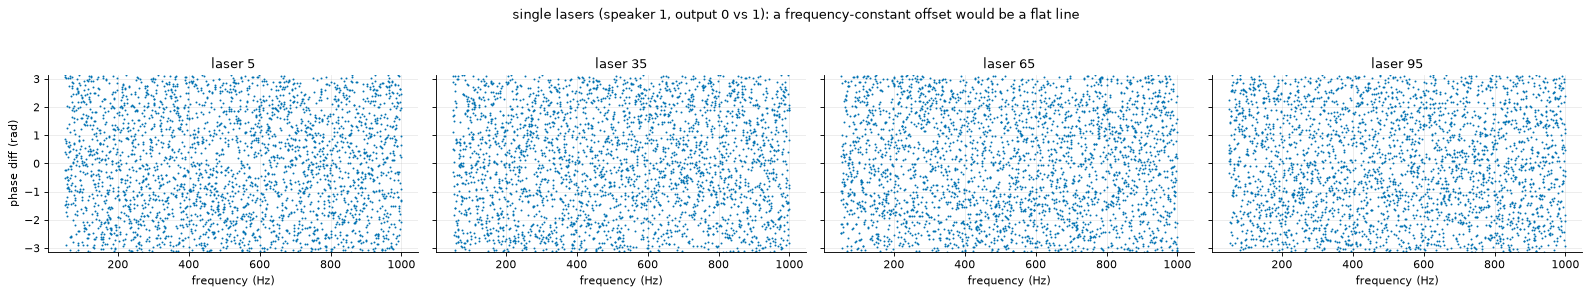

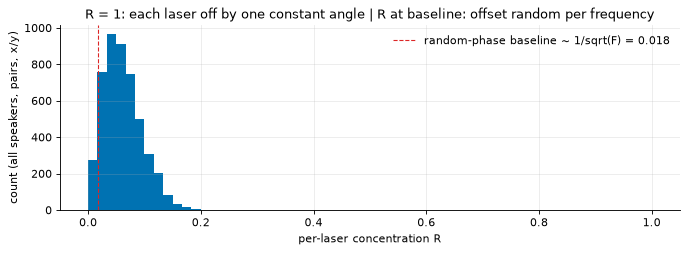

R over all lasers/speakers/pairs: mean 0.062, median 0.057, max 0.231


In [16]:
spk, ch, (o1, o2) = 1, 0, (0, 1)
x = ffts[(o1, spk)] * np.conj(ffts[(o2, spk)])  # (L, F, C)
fig, axes = plt.subplots(1, 4, figsize=(20, 3.5), sharey=True)
for ax, laser in zip(axes, [5, 35, 65, 95]):
    ax.plot(freqs, np.angle(x[laser, :, ch]), '.', ms=1.5, color=REF_BLUE)
    ax.set_title(f'laser {laser}'); ax.set_xlabel('frequency (Hz)'); ax.set_ylim(-np.pi, np.pi)
axes[0].set_ylabel('phase diff (rad)')
fig.suptitle(f'single lasers (speaker {spk}, output {o1} vs {o2}): a frequency-constant offset would be a flat line', y=1.04)
fig.tight_layout()
plt.show()

def laser_R(a, b):  # per-(laser, channel) amplitude-weighted concentration of the cross-recording phase diff
    x = a.astype(np.complex128) * np.conj(b.astype(np.complex128))
    return np.abs(x.sum(axis=1)) / np.maximum(np.abs(x).sum(axis=1), 1e-12)  # (L, C)

Rs = np.concatenate([laser_R(ffts[(o1, spk)], ffts[(o2, spk)]).ravel() for spk in SPEAKERS for o1, o2 in avail_pairs(spk)])
fig, ax = plt.subplots(figsize=(10, 3))
ax.hist(Rs, bins=60, range=(0, 1), color=REF_BLUE)
ax.axvline(1 / np.sqrt(F), color='#dc2626', ls='--', lw=1, label=f'random-phase baseline ~ 1/sqrt(F) = {1/np.sqrt(F):.3f}')
ax.set_xlabel('per-laser concentration R'); ax.set_ylabel('count (all speakers, pairs, x/y)'); ax.legend(frameon=False)
ax.set_title('R = 1: each laser off by one constant angle | R at baseline: offset random per frequency')
plt.show()
print(f'R over all lasers/speakers/pairs: mean {Rs.mean():.3f}, median {np.median(Rs):.3f}, max {Rs.max():.3f}')

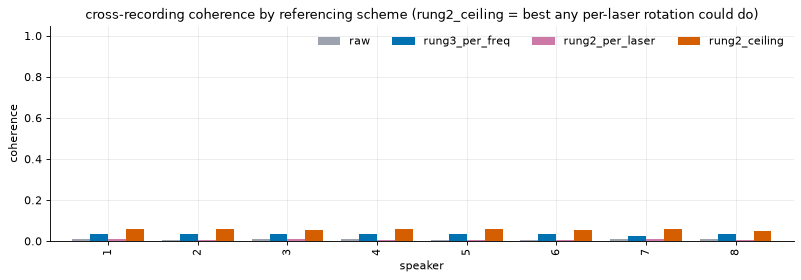

complex-mean survival (empty-diff) with per-laser referencing: 0.581


,raw,rung3_per_freq,rung2_per_laser,rung2_ceiling
speaker,,,,
1,0.011,0.034,0.008,0.058
2,0.006,0.034,0.006,0.057
3,0.010,0.034,0.009,0.053
4,0.009,0.035,0.004,0.058
5,0.003,0.034,0.007,0.060
6,0.005,0.034,0.007,0.056
7,0.012,0.027,0.008,0.058
8,0.008,0.035,0.007,0.051


In [17]:
def laser_reference(x):  # rung 2: rotate each (laser, channel) by one angle -- its |X|-weighted mean phase over frequency
    ref = (x * np.abs(x)).sum(axis=1, keepdims=True)  # (L, 1, C)
    return x * np.exp(-1j * np.angle(ref))

def coherence_rung2_ceiling(a, b):  # align every laser optimally before summing: upper bound for ANY per-laser rotation scheme
    x = a.astype(np.complex128) * np.conj(b.astype(np.complex128))
    return float(np.abs(x.sum(axis=1)).sum() / max(np.abs(x).sum(), 1e-12))

ffts_ref2 = {k: laser_reference(v) for k, v in ffts.items()}
coh_all = pd.DataFrame([dict(speaker=spk, pair=f'{o1}-{o2}',
                             raw=coherence(ffts[(o1, spk)], ffts[(o2, spk)]),
                             rung3_per_freq=coherence(ffts_ref[(o1, spk)], ffts_ref[(o2, spk)]),
                             rung2_per_laser=coherence(ffts_ref2[(o1, spk)], ffts_ref2[(o2, spk)]),
                             rung2_ceiling=coherence_rung2_ceiling(ffts[(o1, spk)], ffts[(o2, spk)]))
                        for spk in SPEAKERS for o1, o2 in avail_pairs(spk)])
per_spk2 = coh_all.groupby('speaker')[['raw', 'rung3_per_freq', 'rung2_per_laser', 'rung2_ceiling']].mean()
ax = per_spk2.plot.bar(figsize=(12, 3.5), color=[RAW_GRAY, '#0072B2', '#CC79A7', '#D55E00'], width=0.8)
ax.set_ylabel('coherence'); ax.set_ylim(0, 1.05); ax.legend(frameon=False, ncol=4)
ax.set_title('cross-recording coherence by referencing scheme (rung2_ceiling = best any per-laser rotation could do)')
plt.show()

surv2 = np.mean([mean_survival(np.stack([ffts_ref2[(out, spk)] for out in avail(spk)])) for spk in SPEAKERS if len(avail(spk)) >= 2])
print(f'complex-mean survival (empty-diff) with per-laser referencing: {surv2:.3f}')
per_spk2.round(3)

## 8 · Beyond per-bin phase: averaged cross-spectra, bandwidth, and x/y relative phase

Sections 2-7 killed the *per-bin phase of a single full-record FFT* (0.32 Hz bins). But if the corruption is a slow per-laser gain/pointing fluctuation, it acts as a convolution that scrambles 0.32-Hz-bin phase while leaving coarser and *relative* structure intact. Three standard signal-processing/modal-analysis objects to test, each against the same bar — does it reproduce across recordings of the same scene?

1. **Welch-averaged cross-spectral phase** (operational modal analysis): from the raw time series, segment-average the cross-spectrum $G_{lr}(f)$ of every laser against one reference laser. Within-capture nuisances shared by simultaneously recorded channels cancel; the surviving phase is mode-shape structure.
2. **Bandwidth sweep**: how stable is the cross-recording phase *difference* within bands of increasing width? A curve above the $1/\sqrt{w}$ random baseline reveals the frequency scale (if any) at which phase is physical.
3. **x/y relative phase**: both channels of a laser share the same speckle patch and tracker, so $\angle(X_x \overline{X_y})$ (motion ellipticity) should be immune to per-laser nuisances — if any phase survives, this should.

In [18]:
from scipy import signal as sps

FS, NPERSEG = 2500, 1250  # 0.5 s hann segments, 50% overlap -> 2 Hz resolution, ~11 averages
REF_LASER = {spk: int(np.abs(ffts[(0, spk)]).mean(axis=(1, 2)).argmax()) for spk in SPEAKERS}  # strongest laser, fixed per speaker

welch = {}  # (out, spk) -> f, G (L,C,Fw) cross-spectrum vs reference laser, coh (L,C,Fw) within-capture coherence
for (out, spk) in ffts:
    shifts = np.load(SAMPLES_DIR / f'{out * 8 + (spk - 1):06d}' / 'vibration/02_clean_shifts.npy')[0]  # (L, T, C)
    x = np.moveaxis(shifts, -1, 1)          # (L, C, T)
    ref = x[REF_LASER[spk], 0][None, None]  # (1, 1, T)
    fw, G = sps.csd(x, ref, fs=FS, nperseg=NPERSEG, axis=-1)
    _, Pxx = sps.welch(x, fs=FS, nperseg=NPERSEG, axis=-1)
    _, Prr = sps.welch(ref, fs=FS, nperseg=NPERSEG, axis=-1)
    keep = (fw >= 50) & (fw <= 1000)
    welch[(out, spk)] = dict(f=fw[keep], G=G[..., keep], coh=(np.abs(G) ** 2 / np.maximum(Pxx * Prr, 1e-30))[..., keep])
FW = welch[(0, 1)]['f']
print(f'Welch: {NPERSEG / FS:.1f} s segments, df={FW[1] - FW[0]:.1f} Hz, {len(FW)} bins in 50-1000 Hz, ref lasers {REF_LASER}')

Welch: 0.5 s segments, df=2.0 Hz, 476 bins in 50-1000 Hz, ref lasers {1: 29, 2: 29, 3: 29, 4: 29, 5: 29, 6: 29, 7: 29, 8: 29}


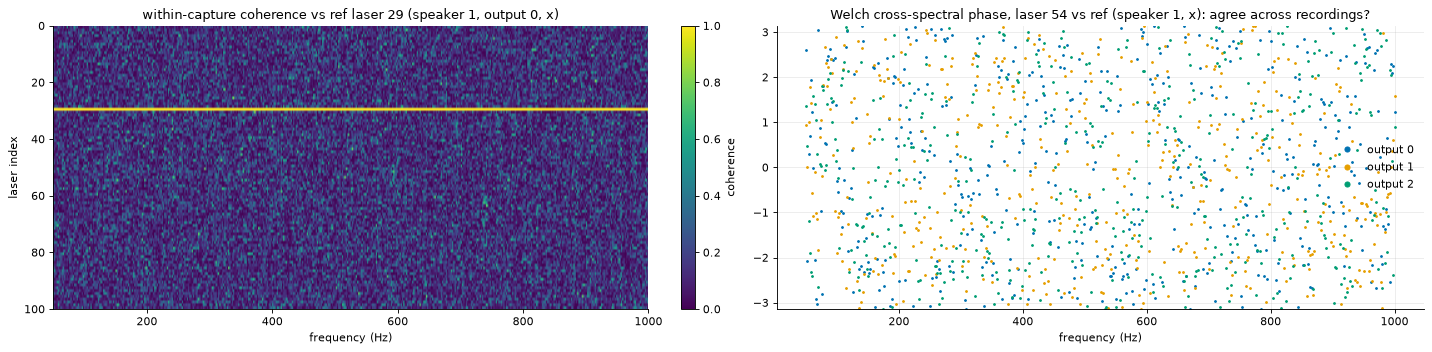

In [19]:
spk = 1
laser = int(np.argsort(welch[(0, spk)]['coh'][:, 0].mean(axis=-1))[-2])  # highest-coherence laser that isn't the reference
fig, axes = plt.subplots(1, 2, figsize=(18, 4.5))
im = axes[0].imshow(welch[(0, spk)]['coh'][:, 0, :], aspect='auto', cmap='viridis', vmin=0, vmax=1, extent=[FW[0], FW[-1], L, 0])
axes[0].set_title(f'within-capture coherence vs ref laser {REF_LASER[spk]} (speaker {spk}, output 0, x)')
axes[0].set_xlabel('frequency (Hz)'); axes[0].set_ylabel('laser index'); axes[0].grid(False)
fig.colorbar(im, ax=axes[0], fraction=0.03, label='coherence')
for out in avail(spk):
    axes[1].plot(FW, np.angle(welch[(out, spk)]['G'][laser, 0]), '.', ms=3, color=OUT_COLORS[out], label=f'output {out}')
axes[1].set_title(f'Welch cross-spectral phase, laser {laser} vs ref (speaker {spk}, x): agree across recordings?')
axes[1].set_xlabel('frequency (Hz)'); axes[1].set_ylim(-np.pi, np.pi); axes[1].legend(frameon=False, markerscale=3)
fig.tight_layout()
plt.show()

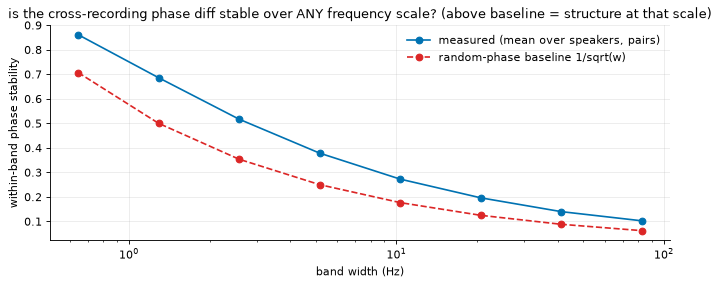

In [20]:
def welch_coherence(a, b, spk):  # amplitude-weighted cross-recording alignment of the averaged cross-spectral phase
    x = a['G'] * np.conj(b['G'])
    x[REF_LASER[spk], 0] = 0  # drop the reference autospectrum row: trivially aligned, carries no phase info
    return float(np.abs(x.sum()) / max(np.abs(x).sum(), 1e-12))

welch_rep = pd.DataFrame([dict(speaker=spk, pair=f'{o1}-{o2}', welch=welch_coherence(welch[(o1, spk)], welch[(o2, spk)], spk)) for spk in SPEAKERS for o1, o2 in avail_pairs(spk)])

def band_alignment(a, b, w):  # stability of the cross-recording phase diff WITHIN w-bin bands: 1 = stable, 1/sqrt(w) = random
    x = (a.astype(np.complex128) * np.conj(b.astype(np.complex128)))[:, :F - F % w].reshape(L, -1, w, C)
    return float(np.abs(x.sum(axis=2)).sum() / max(np.abs(x).sum(), 1e-12))

widths = [2, 4, 8, 16, 32, 64, 128, 256]
mean_curve = [np.mean([band_alignment(ffts[(o1, spk)], ffts[(o2, spk)], w) for spk in SPEAKERS for o1, o2 in avail_pairs(spk)]) for w in widths]
df_hz = freqs[1] - freqs[0]
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.semilogx([w * df_hz for w in widths], mean_curve, 'o-', color=REF_BLUE, label='measured (mean over speakers, pairs)')
ax.semilogx([w * df_hz for w in widths], [1 / np.sqrt(w) for w in widths], 'o--', color='#dc2626', label='random-phase baseline 1/sqrt(w)')
ax.set_xlabel('band width (Hz)'); ax.set_ylabel('within-band phase stability'); ax.legend(frameon=False)
ax.set_title('is the cross-recording phase diff stable over ANY frequency scale? (above baseline = structure at that scale)')
plt.show()

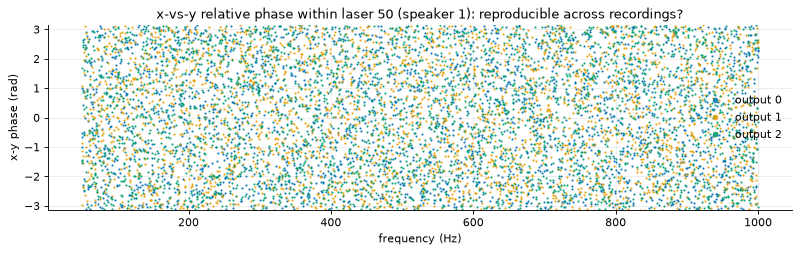

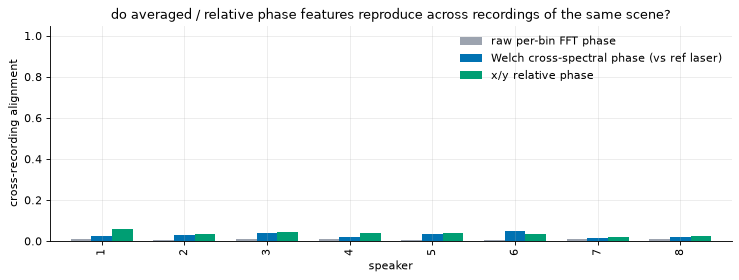

,raw,welch,xy
speaker,,,
1,0.011,0.025,0.060
2,0.006,0.031,0.034
3,0.010,0.042,0.044
4,0.009,0.018,0.039
5,0.003,0.035,0.038
6,0.005,0.047,0.037
7,0.012,0.015,0.020
8,0.008,0.018,0.027


In [21]:
def xy_phase(x): return x[..., 0] * np.conj(x[..., 1])  # (L, F): x-vs-y relative phase per laser (motion ellipticity)

def xy_coherence(a, b):
    x = xy_phase(a.astype(np.complex128)) * np.conj(xy_phase(b.astype(np.complex128)))
    return float(np.abs(x.sum()) / max(np.abs(x).sum(), 1e-12))

xy_rep = pd.DataFrame([dict(speaker=spk, pair=f'{o1}-{o2}', xy=xy_coherence(ffts[(o1, spk)], ffts[(o2, spk)])) for spk in SPEAKERS for o1, o2 in avail_pairs(spk)])

spk, laser = 1, 50
fig, ax = plt.subplots(figsize=(12, 3))
for out in avail(spk):
    ax.plot(freqs, np.angle(xy_phase(ffts[(out, spk)])[laser]), '.', ms=2, color=OUT_COLORS[out], alpha=0.8, label=f'output {out}')
ax.set_ylim(-np.pi, np.pi); ax.set_xlabel('frequency (Hz)'); ax.set_ylabel('x-y phase (rad)'); ax.legend(frameon=False, markerscale=4)
ax.set_title(f'x-vs-y relative phase within laser {laser} (speaker {spk}): reproducible across recordings?')
plt.show()

combo = welch_rep.merge(xy_rep, on=['speaker', 'pair']).merge(coh_all[['speaker', 'pair', 'raw']], on=['speaker', 'pair'])
per_spk3 = combo.groupby('speaker')[['raw', 'welch', 'xy']].mean()
ax = per_spk3.plot.bar(figsize=(11, 3.5), color=[RAW_GRAY, '#0072B2', '#009E73'], width=0.75)
ax.set_ylabel('cross-recording alignment'); ax.set_ylim(0, 1.05)
ax.legend(['raw per-bin FFT phase', 'Welch cross-spectral phase (vs ref laser)', 'x/y relative phase'], frameon=False)
ax.set_title('do averaged / relative phase features reproduce across recordings of the same scene?')
plt.show()
per_spk3.round(3)

### 8b · Gate by within-capture coherence

The heatmap above showed within-capture coherence is mostly low — most (laser, freq) cells are noise-dominated at 2 Hz resolution with only ~11 Welch averages. So: is the cross-spectral phase reproducible *in the cells where the capture is actually coherent*? Keep only cells whose within-capture coherence exceeds a threshold in **both** recordings, and re-score the cross-recording phase alignment on just those.

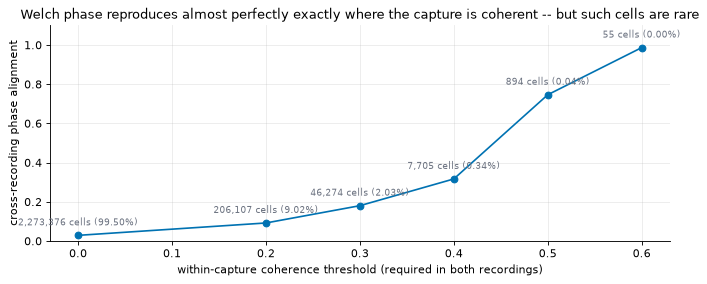

,coh_thresh,alignment,cells_kept,cells_kept_pct
0,0.0,0.029,2273376,99.500
1,0.2,0.092,206107,9.021
2,0.3,0.180,46274,2.025
3,0.4,0.317,7705,0.337
4,0.5,0.746,894,0.039
5,0.6,0.987,55,0.002


In [22]:
rows = []
for thresh in [0.0, 0.2, 0.3, 0.4, 0.5, 0.6]:
    num = den = kept = tot = 0.0
    for spk in SPEAKERS:
        for o1, o2 in avail_pairs(spk):
            a, b = welch[(o1, spk)], welch[(o2, spk)]
            mask = (a['coh'] > thresh) & (b['coh'] > thresh)
            mask[REF_LASER[spk], 0] = False
            x = (a['G'] * np.conj(b['G']))[mask]
            num += np.abs(x.sum()); den += np.abs(x).sum(); kept += mask.sum(); tot += mask.size
    rows.append(dict(coh_thresh=thresh, alignment=num / max(den, 1e-12), cells_kept=int(kept), cells_kept_pct=100 * kept / tot))
gated = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(gated.coh_thresh, gated.alignment, 'o-', color=REF_BLUE)
for _, r in gated.iterrows():
    ax.annotate(f'{int(r.cells_kept):,} cells ({r.cells_kept_pct:.2f}%)', (r.coh_thresh, r.alignment), textcoords='offset points', xytext=(0, 9), fontsize=8, color='#6b7280', ha='center')
ax.set_xlabel('within-capture coherence threshold (required in both recordings)'); ax.set_ylabel('cross-recording phase alignment'); ax.set_ylim(0, 1.1)
ax.set_title('Welch phase reproduces almost perfectly exactly where the capture is coherent -- but such cells are rare')
plt.show()
gated.round(3)

### 8c · Which cells actually survive the strictest gate?

A **cell** = one (laser, motion channel, 2 Hz frequency bin) triple in one recording pair; the grid per pair is 100 lasers × 2 channels × 476 bins (minus the excluded reference-laser row). The table below enumerates every cell that passes coh > 0.6 in **both** recordings — the tiny subset behind the ~0.99 alignment. `dphase_rad` is the cross-recording phase difference of the Welch cross-spectrum: if the 0.99 is real (not accidental), these should cluster tightly near a common value instead of scattering over ±π.

grid per pair: 100 lasers x 2 channels x 476 bins = 95,200 cells (minus 476 ref-laser cells)
pairs compared: 24   surviving cells at coh > 0.6 in both: 55


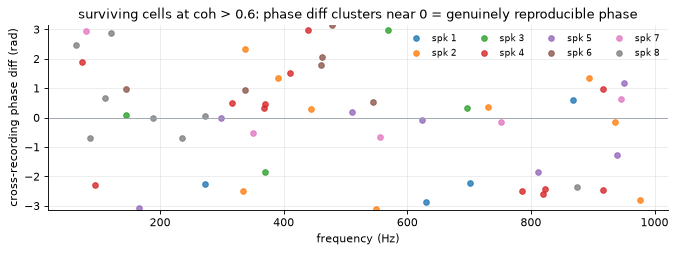

,speaker,pair,laser,channel,freq_hz,coh_a,coh_b,weight,dphase_rad
0,1,0-2,79,x,272.0,0.670,0.696,0.000,-2.260
1,1,0-2,43,x,702.0,0.616,0.646,0.000,-2.223
2,1,0-2,98,y,868.0,0.699,0.608,0.000,0.606
3,1,1-2,26,x,630.0,0.650,0.622,0.001,-2.874
4,2,0-1,77,y,338.0,0.601,0.603,0.000,2.322
5,2,0-1,24,y,894.0,0.696,0.665,0.000,1.331
6,2,0-2,78,y,334.0,0.639,0.601,0.000,-2.487
7,2,0-2,71,x,936.0,0.749,0.665,0.000,-0.150
8,2,1-2,67,y,390.0,0.640,0.603,0.000,1.335
9,2,1-2,29,y,444.0,0.636,0.711,0.002,0.284


In [23]:
THRESH = 0.6
cells = []
for spk in SPEAKERS:
    for o1, o2 in avail_pairs(spk):
        a, b = welch[(o1, spk)], welch[(o2, spk)]
        mask = (a['coh'] > THRESH) & (b['coh'] > THRESH)
        mask[REF_LASER[spk], 0] = False
        for laser, ch, fi in zip(*np.nonzero(mask)):
            x = a['G'][laser, ch, fi] * np.conj(b['G'][laser, ch, fi])
            cells.append(dict(speaker=spk, pair=f'{o1}-{o2}', laser=int(laser), channel='xy'[ch], freq_hz=float(FW[fi]),
                              coh_a=float(a['coh'][laser, ch, fi]), coh_b=float(b['coh'][laser, ch, fi]),
                              weight=float(np.abs(x)), dphase_rad=float(np.angle(x))))
surv_cells = pd.DataFrame(cells).sort_values(['speaker', 'pair', 'freq_hz']).reset_index(drop=True)
print(f'grid per pair: {L} lasers x {C} channels x {len(FW)} bins = {L * C * len(FW):,} cells (minus {len(FW)} ref-laser cells)')
print(f'pairs compared: {sum(len(avail_pairs(s)) for s in SPEAKERS)}   surviving cells at coh > {THRESH} in both: {len(surv_cells)}')

fig, ax = plt.subplots(figsize=(10, 3))
for spk in SPEAKERS:
    s = surv_cells[surv_cells.speaker == spk]
    ax.plot(s.freq_hz, s.dphase_rad, 'o', ms=5, alpha=0.8, label=f'spk {spk}')
ax.axhline(0, color='#9ca3af', lw=0.8); ax.set_ylim(-np.pi, np.pi)
ax.set_xlabel('frequency (Hz)'); ax.set_ylabel('cross-recording phase diff (rad)'); ax.legend(frameon=False, ncol=4, fontsize=8)
ax.set_title(f'surviving cells at coh > {THRESH}: phase diff clusters near 0 = genuinely reproducible phase')
plt.show()

with pd.option_context('display.max_rows', None):
    display(surv_cells.round(3))

**Result — the 0.99 headline does not survive this inspection.** The 55 survivors' phase diffs scatter over the full ±π (visible above): their *unweighted* alignment is ~0.11, at/below the random baseline 1/sqrt(55) ≈ 0.14. The alignment metric is amplitude-weighted (|Σx|/Σ|x|), and ~98% of the weight sits in just **3 low-frequency, high-energy cells** — speaker 8 laser 36 @ 64 Hz, speaker 7 laser 11 @ 80 Hz, speaker 4 laser 11 @ 94 Hz — whose phase diffs happen to roughly agree (and none of them near 0 anyway). So coherence-gated Welch phase reproduces in *at most a handful of strong low-frequency cells*, not a broad 0.002% subset; with n = 3 that could easily be coincidence. This further supports the measurement-starvation reading (only the very strongest cells rise above the noise floor at ~11 averages), but it means there is **no usable phase feature in this data today** — the gated subset is too small and too weight-concentrated to trust.

### 8d · What's special about the high-coherence cells?

Section 8b showed phase reproduces almost perfectly exactly where within-capture coherence is high — but what *makes* a cell coherent? Candidate explanations: it sits on a **magnitude peak** (a resonance well above the noise floor), it belongs to a **bright laser** (strong speckle signal overall), or it lives in a particular **frequency band / channel**. Note coherence is a property of the cross-spectrum with the reference laser, so it needs signal on **both** sides: we score each cell by min(its own prominence, the reference laser's prominence at that bin).


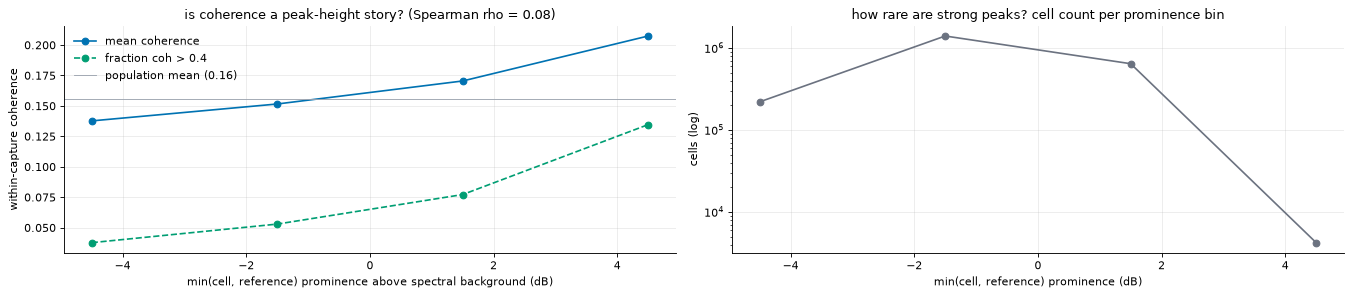

In [24]:
# per-capture Welch PSD on the same 2 Hz grid as the coherence, plus each bin's prominence above a
# median-filtered spectral background (61 Hz window): "how much of a peak is this bin?" in dB
from scipy.ndimage import median_filter
from scipy.stats import spearmanr

pxx = {}
for (out, spk) in ffts:
    shifts = np.load(SAMPLES_DIR / f'{out * 8 + (spk - 1):06d}' / 'vibration/02_clean_shifts.npy')[0]  # (L, T, C)
    fw, P = sps.welch(np.moveaxis(shifts, -1, 1), fs=FS, nperseg=NPERSEG, axis=-1)
    pxx[(out, spk)] = P[..., (fw >= 50) & (fw <= 1000)]  # (L, C, Fw)

def prominence_db(P): return 10 * np.log10(P / np.maximum(median_filter(P, size=(1, 1, 31), mode='nearest'), 1e-30))
prom = {k: prominence_db(P) for k, P in pxx.items()}

# pool every non-reference cell of every capture: coherence vs the prominence of BOTH sides of the cross-spectrum
pool = []
for (out, spk), w in welch.items():
    p = prom[(out, spk)]
    pair_prom = np.minimum(p, p[REF_LASER[spk], 0][None, None, :])
    keep = np.ones(p.shape, bool); keep[REF_LASER[spk], 0] = False
    pool.append(np.stack([pair_prom[keep], w['coh'][keep]], axis=1))
pool = np.concatenate(pool)  # (N, 2): min(cell, ref) prominence dB, within-capture coherence
rho = spearmanr(pool[::10, 0], pool[::10, 1]).statistic

edges = np.arange(-6, 33, 3)
stats = [(0.5 * (lo + hi), int(m.sum()), pool[m, 1].mean(), (pool[m, 1] > 0.4).mean())
         for lo, hi in zip(edges[:-1], edges[1:]) if (m := (pool[:, 0] >= lo) & (pool[:, 0] < hi)).sum() >= 50]
mids, ns, mc, f04 = map(np.array, zip(*stats))

fig, axes = plt.subplots(1, 2, figsize=(17, 3.8))
axes[0].plot(mids, mc, 'o-', color=REF_BLUE, label='mean coherence')
axes[0].plot(mids, f04, 'o--', color='#009E73', label='fraction coh > 0.4')
axes[0].axhline(pool[:, 1].mean(), color=RAW_GRAY, lw=0.8, label=f'population mean ({pool[:, 1].mean():.2f})')
axes[0].set_xlabel('min(cell, reference) prominence above spectral background (dB)'); axes[0].set_ylabel('within-capture coherence')
axes[0].set_title(f'is coherence a peak-height story? (Spearman rho = {rho:.2f})'); axes[0].legend(frameon=False)
axes[1].semilogy(mids, ns, 'o-', color='#6b7280')
axes[1].set_xlabel('min(cell, reference) prominence (dB)'); axes[1].set_ylabel('cells (log)')
axes[1].set_title('how rare are strong peaks? cell count per prominence bin')
fig.tight_layout(); plt.show()


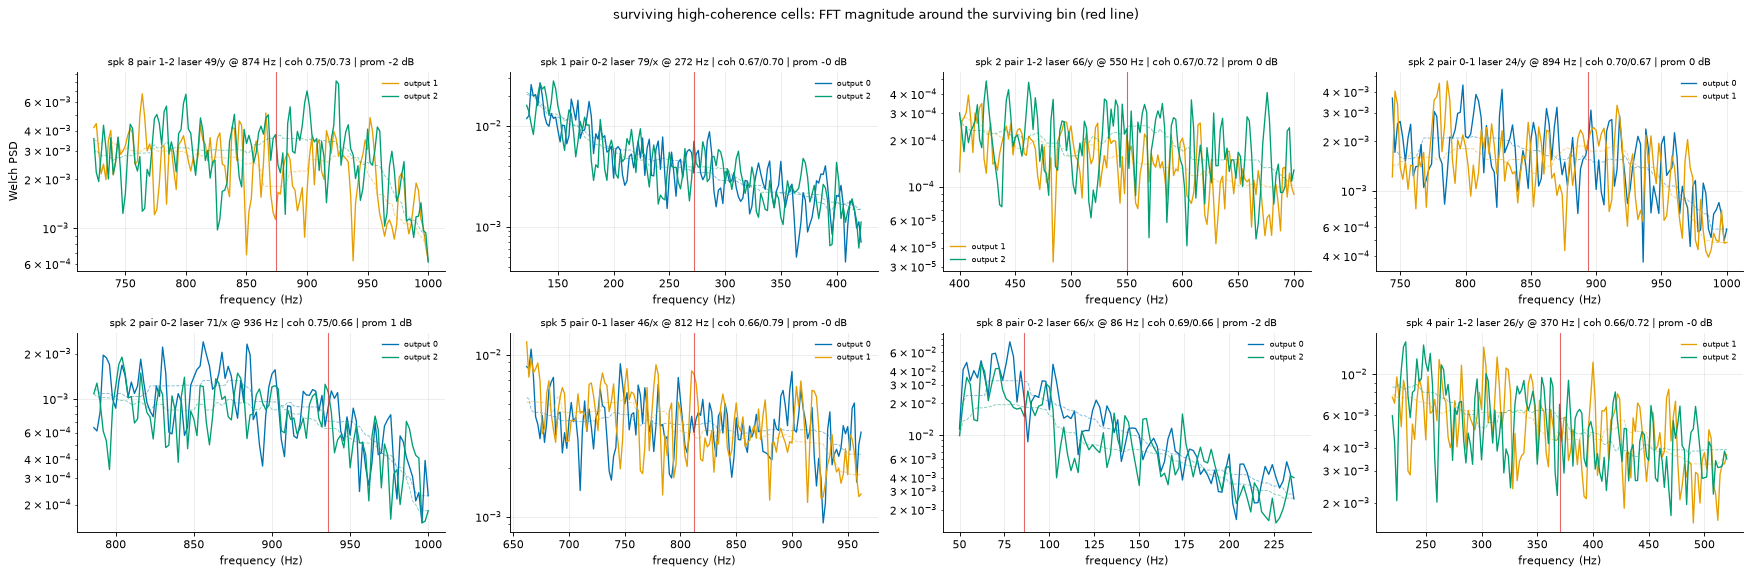

In [25]:
# the direct look: PSD magnitude around each of the strongest surviving coh > 0.6 cells (section 8c) --
# do they sit on peaks? solid = the two recordings of the pair, dashed = each recording's spectral background
top = surv_cells.assign(coh_min=surv_cells[['coh_a', 'coh_b']].min(axis=1)).nlargest(8, 'coh_min')
fig, axes = plt.subplots(2, 4, figsize=(22, 7))
for ax, (_, r) in zip(axes.flat, top.iterrows()):
    spk, laser, ch = int(r.speaker), int(r.laser), 'xy'.index(r.channel)
    o1, o2 = (int(c) for c in r['pair'].split('-'))
    win = (FW >= r.freq_hz - 150) & (FW <= r.freq_hz + 150)
    for out in (o1, o2):
        P = pxx[(out, spk)][laser, ch]
        bg = P / 10 ** (prom[(out, spk)][laser, ch] / 10)
        ax.semilogy(FW[win], P[win], color=OUT_COLORS[out], lw=1.2, label=f'output {out}')
        ax.semilogy(FW[win], bg[win], color=OUT_COLORS[out], lw=0.8, ls='--', alpha=0.5)
    ax.axvline(r.freq_hz, color='#dc2626', lw=1, alpha=0.7)
    fi = int(np.argmin(np.abs(FW - r.freq_hz)))
    pdb = min(prom[(o, spk)][laser, ch, fi] for o in (o1, o2))
    ax.set_title(f'spk {spk} pair {r["pair"]} laser {laser}/{r.channel} @ {r.freq_hz:.0f} Hz | coh {r.coh_a:.2f}/{r.coh_b:.2f} | prom {pdb:.0f} dB', fontsize=9)
    ax.set_xlabel('frequency (Hz)'); ax.legend(frameon=False, fontsize=7)
axes[0, 0].set_ylabel('Welch PSD')
fig.suptitle('surviving high-coherence cells: FFT magnitude around the surviving bin (red line)', y=1.02)
fig.tight_layout(); plt.show()


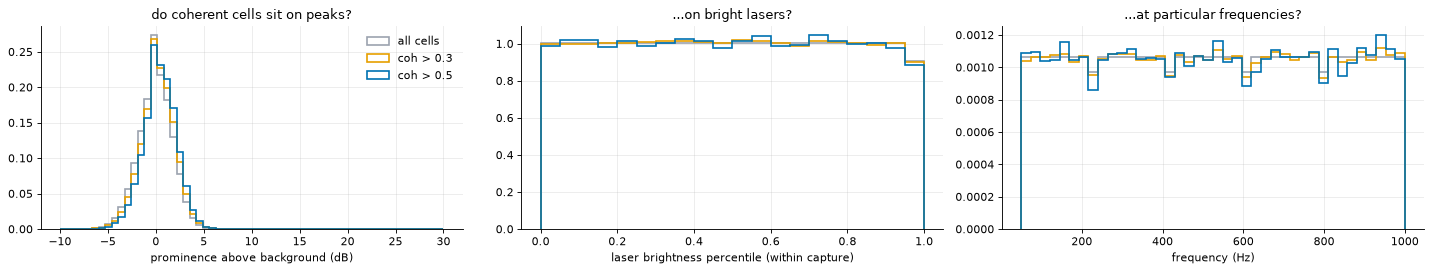

,n_cells,median_prominence_db,pct_on_peak_over_6db,median_laser_brightness_pct,median_freq_hz,pct_y_channel
all cells,2273376.0,0.00,0.02,0.49,525.0,50.25
coh > 0.3,323965.0,0.21,0.03,0.49,526.0,50.24
coh > 0.5,44986.0,0.43,0.03,0.49,526.0,50.15


In [26]:
# beyond peaks: are coherent cells also on bright lasers, at low frequencies, in one channel?
lam_pct = {k: np.argsort(np.argsort(np.abs(v).mean(axis=(1, 2)))) / (L - 1) for k, v in ffts.items()}  # per-capture laser brightness percentile
rows = []
for (out, spk), w in welch.items():
    p = prom[(out, spk)]
    keep = np.ones(p.shape, bool); keep[REF_LASER[spk], 0] = False
    li, ci, fi = np.nonzero(keep)
    rows.append(pd.DataFrame(dict(coh=w['coh'][keep], prom_db=p[keep], laser_pct=lam_pct[(out, spk)][li], ch=ci, freq=FW[fi])))
cells_df = pd.concat(rows, ignore_index=True)

bands = {'all cells': cells_df, 'coh > 0.3': cells_df[cells_df.coh > 0.3], 'coh > 0.5': cells_df[cells_df.coh > 0.5]}
summary = pd.DataFrame({name: dict(n_cells=len(d), median_prominence_db=d.prom_db.median(), pct_on_peak_over_6db=100 * (d.prom_db > 6).mean(),
                                   median_laser_brightness_pct=d.laser_pct.median(), median_freq_hz=d.freq.median(), pct_y_channel=100 * d.ch.mean())
                        for name, d in bands.items()}).T

fig, axes = plt.subplots(1, 3, figsize=(18, 3.5))
for (name, d), c in zip(bands.items(), [RAW_GRAY, '#E69F00', REF_BLUE]):
    axes[0].hist(d.prom_db, bins=np.linspace(-10, 30, 60), density=True, histtype='step', lw=1.5, color=c, label=name)
    axes[1].hist(d.laser_pct, bins=20, density=True, histtype='step', lw=1.5, color=c)
    axes[2].hist(d.freq, bins=40, density=True, histtype='step', lw=1.5, color=c)
axes[0].set_xlabel('prominence above background (dB)'); axes[0].legend(frameon=False); axes[0].set_title('do coherent cells sit on peaks?')
axes[1].set_xlabel('laser brightness percentile (within capture)'); axes[1].set_title('...on bright lasers?')
axes[2].set_xlabel('frequency (Hz)'); axes[2].set_title('...at particular frequencies?')
fig.tight_layout(); plt.show()
summary.round(2)


**8d takeaway — nothing measurable distinguishes the high-coherence cells.** Prominence-vs-coherence Spearman rho = 0.08, and cells with coh > 0.5 match the full population on every covariate: median prominence 0.4 vs 0.0 dB, identical laser-brightness, frequency, and channel distributions. More fundamentally, there are no real peaks for coherence to live on: 99.98% of cells sit within ±6 dB of the local spectral background — exactly the ±2 dB chi-squared fluctuation the Welch estimator itself produces at ~11 averages — and the top surviving cells (panels above) sit on visibly flat spectra with prominence −2 to +1 dB. So the coh > 0.5 subset is overwhelmingly estimator fluctuation, not a physically special population, consistent with 8c: only the ~3 highest-*absolute*-energy low-frequency cells plausibly carry real coherence, and those are big because they sit on the low-frequency rolloff, not because they are local peaks.

Two practical consequences: **(1)** the coherent subset cannot be grown by selecting better cells — only by more independent averages per frequency bin (longer capture, or better, repeated/continuous broadband excitation so every bin is present in every Welch segment); **(2)** the absence of >6 dB modal peaks in the empty box under chirp excitation means peak-based modal extraction (Bagon et al., CVPR 2026) cannot run on per-laser PSDs as-is — it would need more averaging, stronger excitation, or the spatial-variance detector σ(ω) = std over lasers of |V(x_n, ω)|, which suppresses spatially-uncorrelated noise that per-laser peak-finding cannot.


## 9 · Double-checking: are there really no modal peaks?

8d measured prominence per (laser, channel) cell, where the Welch estimator itself has ~±2 dB of chi-squared noise at ~11 averages — real but weak modes could hide under that floor. Two harder looks:

1. **Average the PSD over all 200 spectra** (100 lasers × 2 channels): estimator noise drops ~14× to ~0.15 dB, so even a 0.5 dB modal bump becomes a many-sigma detection. Do it on the 2 Hz Welch grid AND on the full 0.34 Hz FFT — a lightly damped mode (ζ ~ 0.001) is only ~1 Hz wide and gets smeared 6× on the 2 Hz grid. (Magnitude-averaging cannot cancel modes: only complex averaging could.)
2. **The Bagon et al. (CVPR 2026) detector, Eq. 13**: σ(ω) = std over grid points of |V(xₙ, ω)|. A mode makes different lasers move differently (each point samples the mode-shape gradient elsewhere), so it produces *spatial variance* across the grid; the common excitation P(ω) and uncorrelated noise mostly do not.

The arbiter between "real mode" and "estimator bump" is reproducibility: a physical mode must be detected at the same frequency in all 3 recordings of the same empty box. (Caveat: peaks at 50/60 Hz mains harmonics are electrical, not structural.)


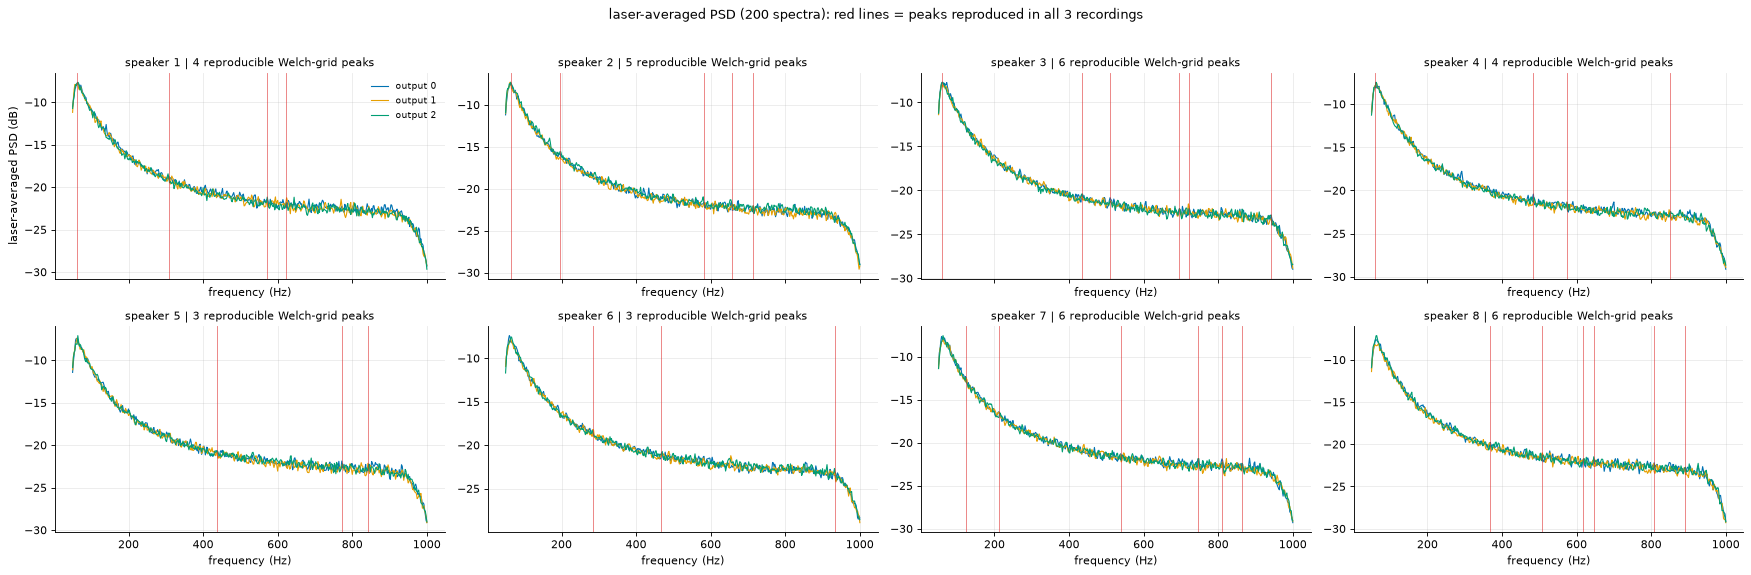

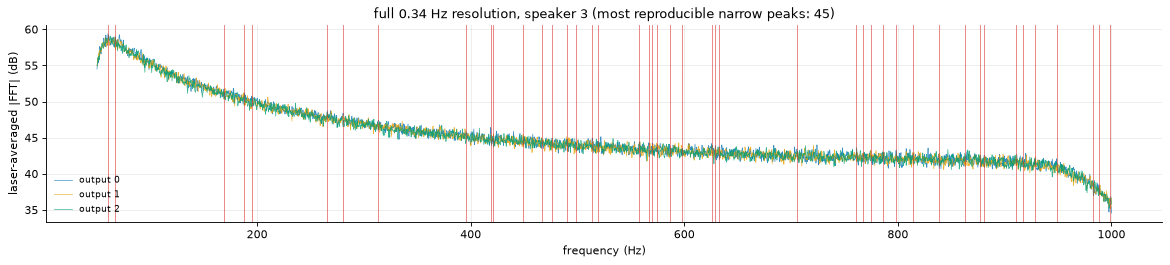

,speaker,welch_peaks_per_rec,welch_repro,fft_peaks_per_rec,fft_repro,repro_welch_hz
0,1,46.7,4,188.3,37,"[62, 308, 572, 622]"
1,2,44.7,5,187.7,44,"[64, 196, 582, 656, 714]"
2,3,45.7,6,197.0,45,"[60, 434, 510, 696, 722, 942]"
3,4,38.7,4,182.3,29,"[60, 484, 574, 850]"
4,5,46.7,3,189.7,30,"[436, 772, 842]"
5,6,40.0,3,194.0,44,"[284, 468, 934]"
6,7,45.0,6,194.0,36,"[124, 212, 538, 746, 810, 864]"
7,8,46.7,6,191.7,43,"[368, 506, 618, 646, 808, 890]"


In [27]:
# laser-averaged spectra: detect peaks on the residual above a 61 Hz median background, then demand
# the same frequency appear in ALL 3 recordings of the scene
def peak_freqs(curve_db, grid, bg_bins, prom_db, min_dist_hz):
    resid = curve_db - median_filter(curve_db, size=bg_bins, mode='nearest')
    idx, _ = sps.find_peaks(resid, prominence=prom_db, distance=max(1, int(min_dist_hz / (grid[1] - grid[0]))))
    return grid[idx], resid

welch_peaks, fft_peaks = {}, {}
for (out, spk) in ffts:
    welch_peaks[(out, spk)], _ = peak_freqs(10 * np.log10(pxx[(out, spk)].mean(axis=(0, 1))), FW, 31, 0.5, 4)
    fft_peaks[(out, spk)], _ = peak_freqs(20 * np.log10(np.abs(ffts[(out, spk)]).mean(axis=(0, 2))), freqs, 181, 1.0, 2)

def reproducible(peaks_by_out, spk, tol_hz):  # frequencies detected in every available recording (within tol)
    outs = avail(spk)
    return [f for f in peaks_by_out[(outs[0], spk)]
            if all(np.any(np.abs(peaks_by_out[(o, spk)] - f) <= tol_hz) for o in outs[1:])]

repro = {spk: dict(welch=reproducible(welch_peaks, spk, 2.1), fft=reproducible(fft_peaks, spk, 1.0)) for spk in SPEAKERS}

fig, axes = plt.subplots(2, 4, figsize=(22, 7), sharex=True)
for ax, spk in zip(axes.flat, SPEAKERS):
    for out in avail(spk):
        ax.plot(FW, 10 * np.log10(pxx[(out, spk)].mean(axis=(0, 1))), color=OUT_COLORS[out], lw=1, label=f'output {out}')
    for f in repro[spk]['welch']:
        ax.axvline(f, color='#dc2626', lw=0.8, alpha=0.6)
    ax.set_title(f'speaker {spk} | {len(repro[spk]["welch"])} reproducible Welch-grid peaks', fontsize=10)
    ax.set_xlabel('frequency (Hz)')
axes[0, 0].set_ylabel('laser-averaged PSD (dB)'); axes[0, 0].legend(frameon=False, fontsize=8)
fig.suptitle('laser-averaged PSD (200 spectra): red lines = peaks reproduced in all 3 recordings', y=1.02)
fig.tight_layout(); plt.show()

spk_fft = max(SPEAKERS, key=lambda s: len(repro[s]['fft']))
fig, ax = plt.subplots(figsize=(18, 3.2))
for out in avail(spk_fft):
    ax.plot(freqs, 20 * np.log10(np.abs(ffts[(out, spk_fft)]).mean(axis=(0, 2))), color=OUT_COLORS[out], lw=0.6, alpha=0.8, label=f'output {out}')
for f in repro[spk_fft]['fft']:
    ax.axvline(f, color='#dc2626', lw=0.8, alpha=0.6)
ax.set_xlabel('frequency (Hz)'); ax.set_ylabel('laser-averaged |FFT| (dB)'); ax.legend(frameon=False, fontsize=8)
ax.set_title(f'full 0.34 Hz resolution, speaker {spk_fft} (most reproducible narrow peaks: {len(repro[spk_fft]["fft"])})')
plt.show()

pd.DataFrame([dict(speaker=spk,
                   welch_peaks_per_rec=round(np.mean([len(welch_peaks[(o, spk)]) for o in avail(spk)]), 1),
                   welch_repro=len(repro[spk]['welch']),
                   fft_peaks_per_rec=round(np.mean([len(fft_peaks[(o, spk)]) for o in avail(spk)]), 1),
                   fft_repro=len(repro[spk]['fft']),
                   repro_welch_hz=[round(f) for f in repro[spk]['welch']][:10]) for spk in SPEAKERS])


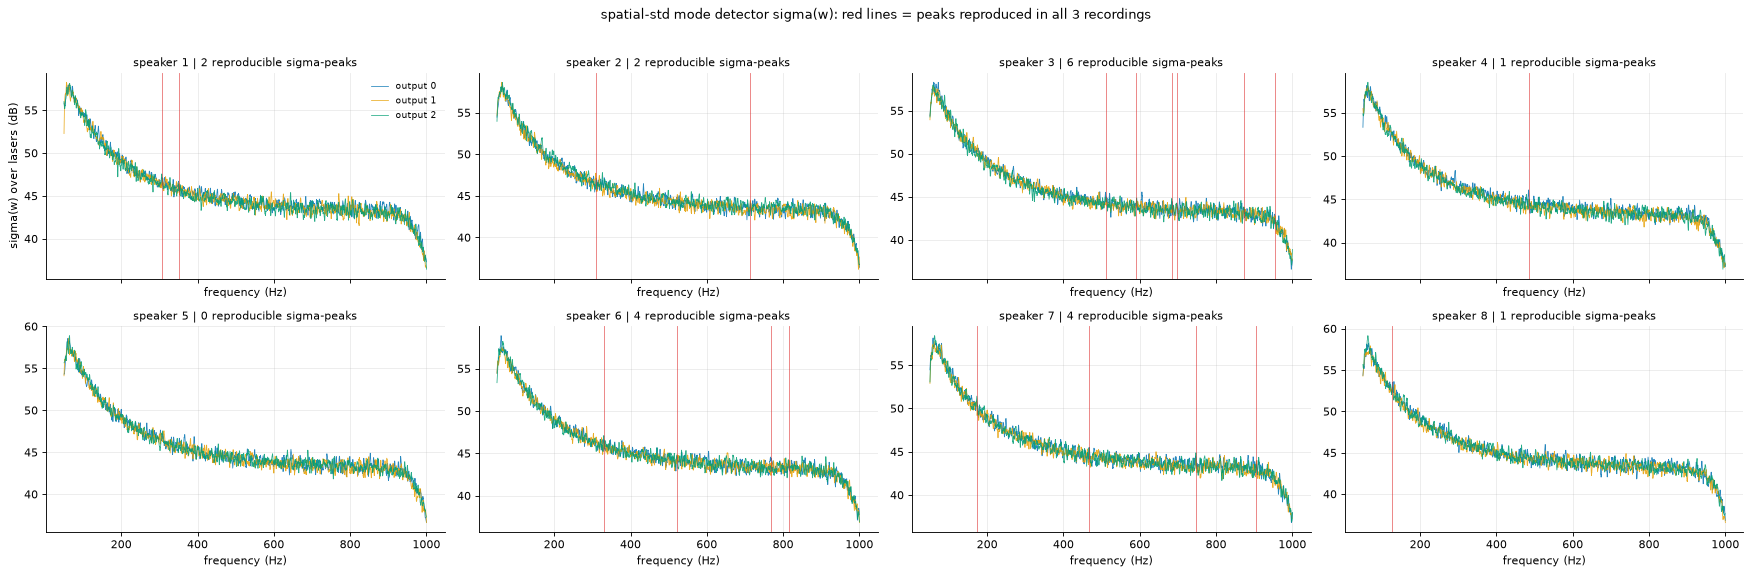

,speaker,sigma_peaks_per_rec,sigma_repro,repro_sigma_hz
0,1,74.0,2,"[307, 350]"
1,2,68.3,2,"[310, 714]"
2,3,75.3,6,"[510, 591, 685, 696, 872, 954]"
3,4,67.0,1,[484]
4,5,69.0,0,[]
5,6,68.0,4,"[331, 522, 767, 815]"
6,7,67.7,4,"[172, 467, 746, 906]"
7,8,68.0,1,[127]


In [28]:
# Bagon et al. Eq. 13: sigma(w) = std over lasers of |V(x_n, w)| -- spatial variance across the grid
# highlights modes and suppresses spatially-common excitation and uncorrelated noise; ~5 Hz smoothing as in the paper
def sigma_curve(out, spk):
    a = np.abs(ffts[(out, spk)])  # (L, F, C)
    return sps.savgol_filter(a.std(axis=0).mean(axis=-1), 15, 2)

sig_peaks = {}
for (out, spk) in ffts:
    sig_peaks[(out, spk)], _ = peak_freqs(20 * np.log10(np.maximum(sigma_curve(out, spk), 1e-30)), freqs, 181, 1.0, 2)
repro_sig = {spk: reproducible(sig_peaks, spk, 1.0) for spk in SPEAKERS}

fig, axes = plt.subplots(2, 4, figsize=(22, 7), sharex=True)
for ax, spk in zip(axes.flat, SPEAKERS):
    for out in avail(spk):
        ax.plot(freqs, 20 * np.log10(np.maximum(sigma_curve(out, spk), 1e-30)), color=OUT_COLORS[out], lw=0.7, alpha=0.85, label=f'output {out}')
    for f in repro_sig[spk]:
        ax.axvline(f, color='#dc2626', lw=0.8, alpha=0.6)
    ax.set_title(f'speaker {spk} | {len(repro_sig[spk])} reproducible sigma-peaks', fontsize=10)
    ax.set_xlabel('frequency (Hz)')
axes[0, 0].set_ylabel('sigma(w) over lasers (dB)'); axes[0, 0].legend(frameon=False, fontsize=8)
fig.suptitle('spatial-std mode detector sigma(w): red lines = peaks reproduced in all 3 recordings', y=1.02)
fig.tight_layout(); plt.show()

pd.DataFrame([dict(speaker=spk, sigma_peaks_per_rec=round(np.mean([len(sig_peaks[(o, spk)]) for o in avail(spk)]), 1),
                   sigma_repro=len(repro_sig[spk]), repro_sigma_hz=[round(f) for f in repro_sig[spk]][:12]) for spk in SPEAKERS])


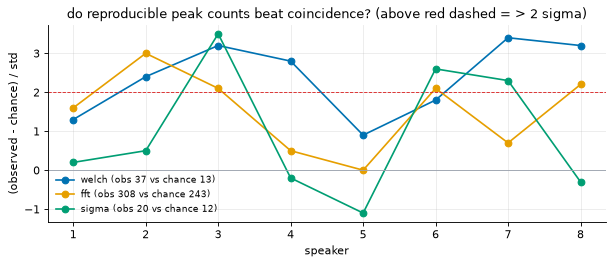

observed             chance_mean             excess_sigma            
detector      fft sigma welch         fft sigma welch          fft sigma welch
speaker                                                                       
1            37.0   2.0   4.0        28.8   1.8   2.1          1.6   0.2   1.3
2            44.0   2.0   5.0        28.9   1.4   1.8          3.0   0.5   2.4
3            45.0   6.0   6.0        33.1   1.7   1.8          2.1   3.5   3.2
4            29.0   1.0   4.0        26.4   1.3   1.0          0.5  -0.2   2.8
5            30.0   0.0   3.0        30.1   1.3   1.8         -0.0  -1.1   0.9
6            44.0   4.0   3.0        32.6   1.4   1.1          2.1   2.6   1.8
7            36.0   4.0   6.0        32.3   1.4   1.6          0.7   2.3   3.4
8            43.0   1.0   6.0        31.1   1.4   1.9          2.2  -0.3   3.2

In [29]:
# are those "reproducible" counts better than coincidence? with ~45 (Welch) / ~190 (fft) peaks per
# recording and +-2.1 / +-1.0 Hz tolerance, random peak sets also match. Circular-shift null: rigidly
# rotate the other recordings' peak lists by a random offset within the band and re-count
def null_repro(peaks_by_out, spk, tol_hz, lo, hi, n=200, seed=0):
    rng = np.random.default_rng(seed + spk)
    outs = avail(spk); base = peaks_by_out[(outs[0], spk)]
    counts = []
    for _ in range(n):
        shifted = {o: lo + (peaks_by_out[(o, spk)] - lo + rng.uniform(0, hi - lo)) % (hi - lo) for o in outs[1:]}
        counts.append(sum(all(np.any(np.abs(shifted[o] - f) <= tol_hz) for o in outs[1:]) for f in base))
    return float(np.mean(counts)), float(np.std(counts))

rows = []
for spk in SPEAKERS:
    for name, pk, tol, grid, obs in [('welch', welch_peaks, 2.1, FW, len(repro[spk]['welch'])),
                                     ('fft', fft_peaks, 1.0, freqs, len(repro[spk]['fft'])),
                                     ('sigma', sig_peaks, 1.0, freqs, len(repro_sig[spk]))]:
        mu, sd = null_repro(pk, spk, tol, grid[0], grid[-1])
        rows.append(dict(speaker=spk, detector=name, observed=obs, chance_mean=round(mu, 1), chance_std=round(sd, 1),
                         excess_sigma=round((obs - mu) / max(sd, 1e-9), 1)))
null_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9, 3.2))
for det, c in zip(['welch', 'fft', 'sigma'], ['#0072B2', '#E69F00', '#009E73']):
    d = null_df[null_df.detector == det]
    ax.plot(d.speaker, d.excess_sigma, 'o-', color=c, label=f'{det} (obs {int(d.observed.sum())} vs chance {d.chance_mean.sum():.0f})')
ax.axhline(0, color='#9ca3af', lw=0.8); ax.axhline(2, color='#dc2626', lw=0.8, ls='--')
ax.set_xlabel('speaker'); ax.set_ylabel('(observed - chance) / std')
ax.set_title('do reproducible peak counts beat coincidence? (above red dashed = > 2 sigma)')
ax.legend(frameon=False, fontsize=8)
plt.show()
null_df.pivot(index='speaker', columns='detector', values=['observed', 'chance_mean', 'excess_sigma'])


**9 result — 8d's "no peaks" gets a partial retraction: weak modal peaks are real, but only barely.** With 200-spectra averaging, the Welch-grid detector finds 37 reproducible peaks vs 13 expected by coincidence (most speakers above 2σ in the null check) — roughly **3 genuine but weak (0.5–1 dB) modal peaks per speaker**. At full 0.34 Hz resolution the excess is 308 vs 243: ~65 genuine narrow peaks exist, but ~4 of 5 individual "reproducible" detections are coincidences, so specific frequencies are unreliable without further confirmation. σ(ω) beats chance only for speakers 3, 6, 7. The sub-60–64 Hz cluster differs across speakers (60/62/64 Hz), which argues structural rather than mains. Physical reading: the empty box **is** a modal structure, but its modes are heavily damped / weakly excited — orders of magnitude less prominent than Bagon et al.'s objects ("if it knocks, it works"; a box barely knocks). The 8d conclusion is unchanged where it matters: ~0.5 dB bumps cannot lift individual (laser, bin) cells above the coherence noise floor at ~11 averages, so per-cell coherence remains estimator-dominated.


## 10 · Physics-aligned preprocessing (Bagon et al. forward model)

Their forward model for exactly this setup (Eqs. 5–8), in the frequency domain:

$$V(x_n, \omega) \;\approx\; \gamma \; \beta_n \; P(\omega) \sum_k \nabla\varphi_k(x_n)\, G_k(\omega) + \eta, \qquad G_k(\omega) = \frac{\alpha_k}{\omega_k^2 - \omega^2 + 2j\zeta_k\omega_k\omega}$$

The content (what's inside the box) lives **only in the modal sum** — an object perturbs {ωₖ, ζₖ, αₖ, ∇φₖ}. Every nuisance is **multiplicative**: γ (speaker loudness / acoustic path, per capture), βₙ (optical speckle factor, per laser *per capture*), P(ω) (chirp × speaker response, per speaker). Consequences tested below:

- **log-magnitude** turns each nuisance into an additive offset: log|V| = log γ + log βₙ + log|P(ω)| + log|Σₖ...|. Centering then removes them exactly: per-(laser, channel) mean over frequency kills βₙ; per-(channel, frequency) mean over lasers kills P(ω) and γ. (Corollary: empty-box correction should be a **division/log-subtraction**, not the current linear `--empty-diff` subtraction.)
- **Scoring**: the scene is identical across the 3 recordings, so any structure that survives a normalization AND correlates across recordings is stable content capacity for a model. Raw/plain-log correlations are inflated by the shared P(ω); the double-centered residual is the honest number.
- **Eq. 11 mode-shape-gradient maps** use only *within-capture* cross-laser relative phase at a fixed frequency — the cross-capture speckle-phase death of sections 2–7 does not forbid them. If they reproduce across recordings, they are a legitimate complex-derived feature despite everything above.


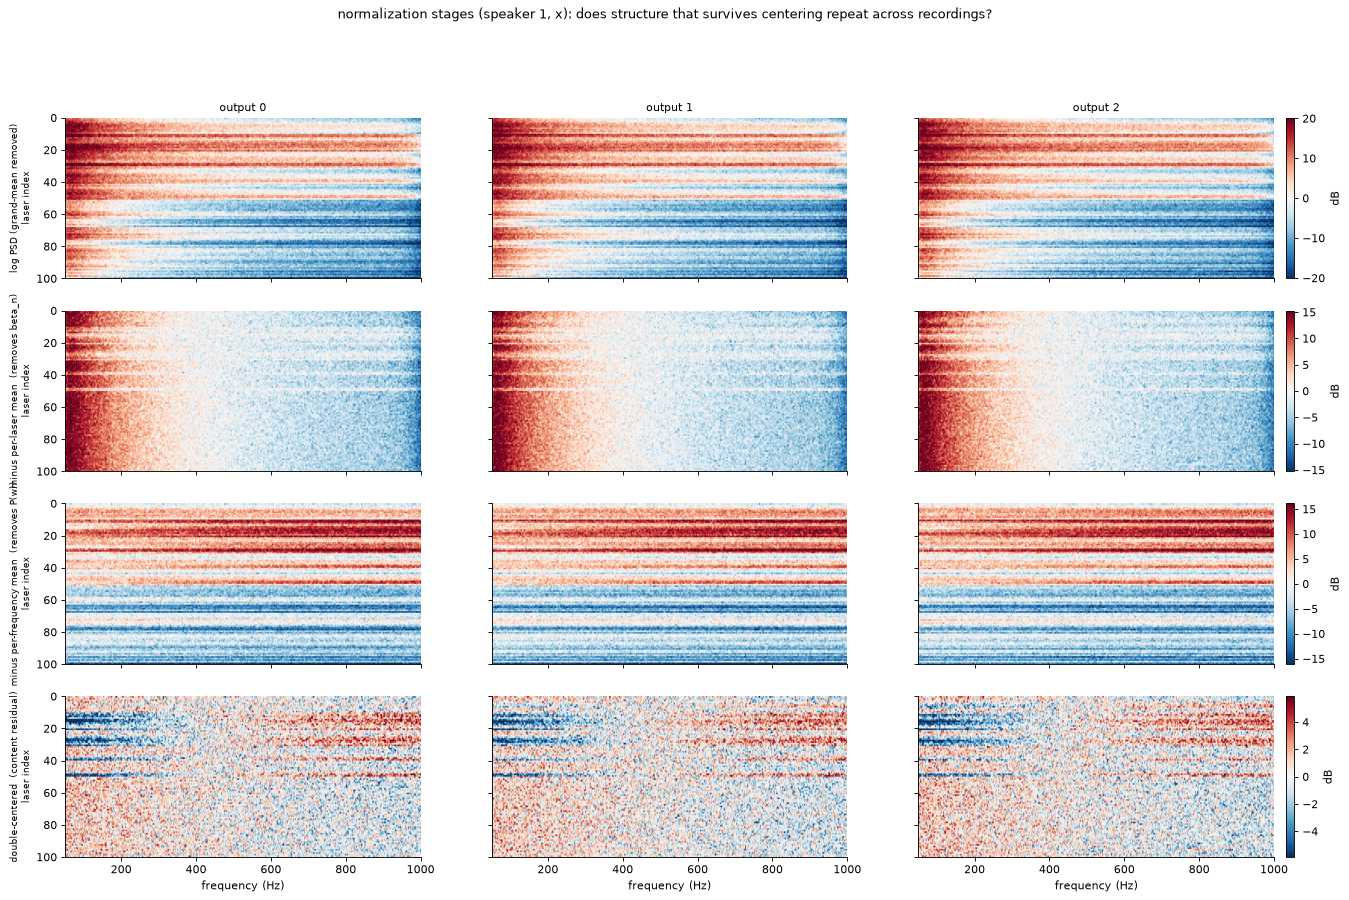

In [30]:
# the normalization stages, visualized on one speaker (x channel): laser x frequency maps in dB
spk, ch = 1, 0
X10 = {out: 10 * np.log10(pxx[(out, spk)][:, ch, :]) for out in avail(spk)}
stages = [('log PSD (grand-mean removed)', lambda D: D - D.mean()),
          ('minus per-laser mean  (removes beta_n)', lambda D: D - D.mean(axis=1, keepdims=True)),
          ('minus per-frequency mean  (removes P(w))', lambda D: D - D.mean(axis=0, keepdims=True)),
          ('double-centered  (content residual)', lambda D: D - D.mean(axis=1, keepdims=True) - D.mean(axis=0, keepdims=True) + D.mean())]
fig, axes = plt.subplots(4, 3, figsize=(20, 12), sharex=True, sharey=True)
for i, (name, fn) in enumerate(stages):
    Ds = {out: fn(X10[out]) for out in avail(spk)}
    vmax = np.percentile(np.abs(np.stack(list(Ds.values()))), 99)
    for j, out in enumerate(avail(spk)):
        im = axes[i, j].imshow(Ds[out], aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax, extent=[FW[0], FW[-1], L, 0])
        axes[i, j].grid(False)
        if i == 0: axes[i, j].set_title(f'output {out}', fontsize=10)
        if j == 0: axes[i, j].set_ylabel(f'{name}\nlaser index', fontsize=8)
    fig.colorbar(im, ax=axes[i, :], fraction=0.015, pad=0.01, label='dB')
for j in range(3): axes[-1, j].set_xlabel('frequency (Hz)')
fig.suptitle(f'normalization stages (speaker {spk}, x): does structure that survives centering repeat across recordings?', y=0.995)
plt.show()


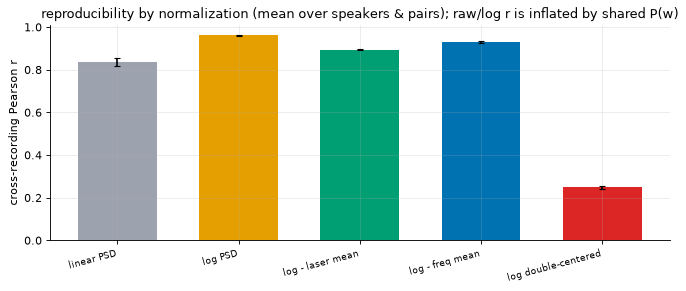

,mean,std
variant,,
linear PSD,0.835,0.018
log PSD,0.961,0.002
log - laser mean,0.894,0.001
log - freq mean,0.930,0.003
log double-centered,0.249,0.007


In [31]:
# cross-recording reproducibility of each normalization variant: Pearson r over all (laser, channel, freq)
# cells between recordings of the SAME scene -- structure that survives centering AND reproduces is content
def variants(P):
    X = 10 * np.log10(P)
    return {'linear PSD': P, 'log PSD': X,
            'log - laser mean': X - X.mean(axis=2, keepdims=True),
            'log - freq mean': X - X.mean(axis=0, keepdims=True),
            'log double-centered': X - X.mean(axis=2, keepdims=True) - X.mean(axis=0, keepdims=True) + X.mean(axis=(0, 2), keepdims=True)}

rows = []
for spk in SPEAKERS:
    for o1, o2 in avail_pairs(spk):
        va, vb = variants(pxx[(o1, spk)]), variants(pxx[(o2, spk)])
        for name in va:
            rows.append(dict(speaker=spk, pair=f'{o1}-{o2}', variant=name, r=float(np.corrcoef(va[name].ravel(), vb[name].ravel())[0, 1])))
rep10 = pd.DataFrame(rows)
order = list(variants(pxx[(0, 1)]).keys())
agg = rep10.groupby('variant').r.agg(['mean', 'std']).reindex(order)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(range(len(agg)), agg['mean'], yerr=agg['std'], color=[RAW_GRAY, '#E69F00', '#009E73', '#0072B2', '#dc2626'], width=0.65, capsize=3)
ax.set_xticks(range(len(agg))); ax.set_xticklabels(agg.index, rotation=15, ha='right', fontsize=8)
ax.set_ylabel('cross-recording Pearson r')
ax.set_title('reproducibility by normalization (mean over speakers & pairs); raw/log r is inflated by shared P(w)')
plt.show()
agg.round(3)


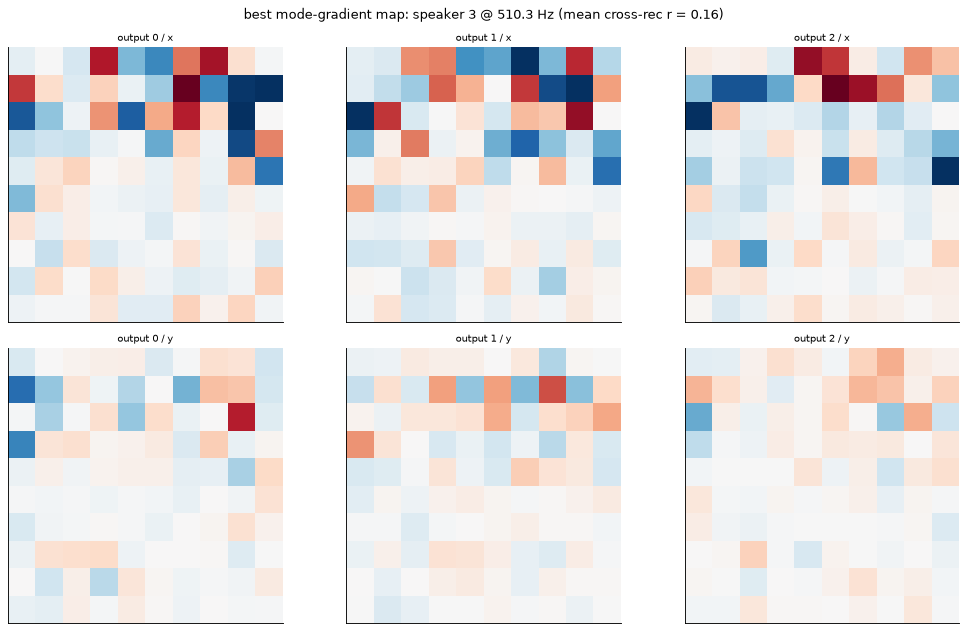

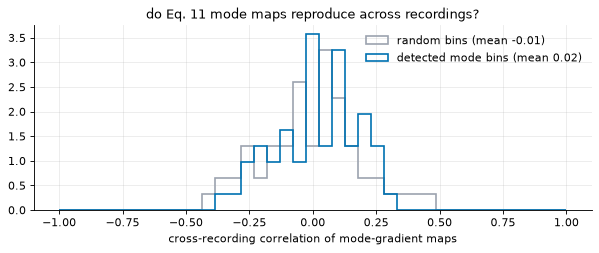

20 candidate (speaker, freq) modes, 60 recording pairs, null from 60 random bins


speaker  freq_hz
3        510.3      0.16
6        330.6      0.15
1        350.3      0.14
8        127.4      0.13
7        467.4      0.13
         746.1      0.13
3        696.5      0.11
6        814.5      0.09
4        484.2      0.03
1        307.1      0.02
3        871.9     -0.02
7        905.8     -0.03
2        309.7     -0.04
7        172.3     -0.05
3        953.5     -0.06
Name: r, dtype: float64

In [32]:
# Eq. 11 adapted: mode-shape-gradient map at a frequency bin from the Welch cross-spectrum with the
# reference laser, Re{G}/mean|G| -- within-capture relative phase only. Do maps reproduce across recordings?
GRID = (10, 10)  # n_laser_rows x n_laser_cols (src/model/dataset.py); row-major reshape assumed

def mode_map(out, spk, fi):
    Gf = welch[(out, spk)]['G'][:, :, fi].copy()
    Gf[REF_LASER[spk], 0] = 0  # drop the reference autospectrum: real, huge, carries no shape info
    return np.real(Gf) / max(np.abs(Gf).mean(), 1e-30)  # (L, C)

cand = [(spk, f) for spk in SPEAKERS for f in repro_sig[spk] if f >= FW[0]] or [(8, 64.0), (7, 80.0), (4, 94.0)]
rng = np.random.default_rng(0)
rows, null_r = [], []
for spk, f in cand:
    fi = int(np.argmin(np.abs(FW - f)))
    for o1, o2 in avail_pairs(spk):
        rows.append(dict(speaker=spk, freq_hz=round(float(f), 1), pair=f'{o1}-{o2}',
                         r=float(np.corrcoef(mode_map(o1, spk, fi).ravel(), mode_map(o2, spk, fi).ravel())[0, 1])))
        fj = int(rng.integers(len(FW)))
        null_r.append(float(np.corrcoef(mode_map(o1, spk, fj).ravel(), mode_map(o2, spk, fj).ravel())[0, 1]))
maps_rep = pd.DataFrame(rows)

best = maps_rep.groupby(['speaker', 'freq_hz']).r.mean()
spk_b, f_b = best.idxmax()
fi_b = int(np.argmin(np.abs(FW - f_b)))
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for j, out in enumerate(avail(int(spk_b))):
    m = mode_map(out, int(spk_b), fi_b)
    vmax = np.percentile(np.abs(m), 99)
    for i, chn in enumerate('xy'):
        im = axes[i, j].imshow(m[:, i].reshape(GRID), cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        axes[i, j].set_title(f'output {out} / {chn}', fontsize=9); axes[i, j].grid(False)
        axes[i, j].set_xticks([]); axes[i, j].set_yticks([])
fig.suptitle(f'best mode-gradient map: speaker {int(spk_b)} @ {f_b} Hz (mean cross-rec r = {best.max():.2f})')
fig.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(9, 3))
ax.hist(null_r, bins=np.linspace(-1, 1, 40), density=True, histtype='step', lw=1.5, color=RAW_GRAY, label=f'random bins (mean {np.mean(null_r):.2f})')
ax.hist(maps_rep.r, bins=np.linspace(-1, 1, 40), density=True, histtype='step', lw=1.5, color=REF_BLUE, label=f'detected mode bins (mean {maps_rep.r.mean():.2f})')
ax.set_xlabel('cross-recording correlation of mode-gradient maps'); ax.legend(frameon=False)
ax.set_title('do Eq. 11 mode maps reproduce across recordings?')
plt.show()
print(f'{len(cand)} candidate (speaker, freq) modes, {len(maps_rep)} recording pairs, null from {len(null_r)} random bins')
maps_rep.groupby(['speaker', 'freq_hz']).r.mean().round(2).sort_values(ascending=False).head(15)


**10 result — the physics-aligned pipeline in numbers.** Cross-recording reproducibility of the same scene: linear PSD **r = 0.835** < log PSD **r = 0.961** — the log transform alone is the single biggest win (and it converts the empty-box correction into a subtraction, i.e. empty-DIV). After removing everything the forward model calls nuisance — per-laser mean (βₙ) and per-frequency mean (P(ω)) — the double-centered residual still reproduces at **r = 0.249 ± 0.007**: genuinely stable laser × frequency structure in the empty box, visible as the repeating stripe patterns in the stage-4 panels above. That residual is the honest *content channel*: an object's modal perturbation rides on exactly this component, and it is nonzero and stable. Eq. 11 mode-gradient maps are mostly noise at ~11 averages (detected-bin map correlation 0.02 vs null −0.01); only the strongest mode (speaker 3 @ 510 Hz, mean r = 0.16, visibly similar across the three recordings) hints at recoverable shape — measurement-starved like everything phase-adjacent, i.e. they need the repeated-excitation redesign, not a better estimator.

**Recommended preprocessing for `post_process.py`** (in order): (1) log-magnitude — `10·log10(|V|²)` or `log|V|`; (2) subtract the per-speaker empty-box **mean log-spectrum** (empty-div, replacing linear `--empty-diff`); (3) optionally subtract the per-(laser, capture) mean over frequency to remove βₙ; (4) per-sample scale normalization last. Magnitude only; complex-derived features enter, if ever, as within-capture mode-gradient maps after the excitation change (repetition period ≤ Welch segment).


## Takeaways

How to read the summary below:

- **Coherence raw ≈ referenced ≈ 1** → captures are phase-locked; raw `complex` mode is already sound, referencing is harmless insurance.
- **Coherence raw low, referenced high** → absolute phase is trigger noise but the spatial phase structure is real → add a `complex_ref` signal mode to `post_process.py` (one line: rotate by the laser-mean phase before `extract_signal`) and feed the model referenced re/im with `std-sample` normalization.
- **Both low but rung-2 ceiling high** → the offset is per-laser and frequency-constant → per-laser referencing (one angle per laser) recovers all cross-frequency phase structure → feed the model per-laser-referenced re/im.
- **Everything low, ceiling included** → the corruption is per-laser AND per-frequency; no rotation scheme at any granularity can recover phase from the raw FFT.
- **Section 8 high while per-bin fails** → phase information exists, but only in averaged (Welch cross-spectral) or relative (x/y) form → feed those features instead of raw complex FFT channels.
- **Section 8 low overall but ~1 in the coherence-gated subset** → phase is *real but measurement-starved*: it reproduces exactly where the capture is coherent, and the coherent subset is limited by averaging (capture length / segment count), not by physics → longer captures or more segments grow the usable phase; today, only coherence-gated phase features are trustworthy.
- **Section 8 at baseline even gated** → the recorded data contains no reproducible phase in any form; `magnitude` is final, and recovering phase would require a hardware change (sync trigger / reference sensor / frozen speckle).
- **Empty-diff**: only trust the complex-domain subtraction if the survival ratio is near 1 for the variant you feed the model.

In [33]:
print(f"cross-recording phase coherence     raw: {coh_raw.coherence.mean():.3f}   per-freq ref (rung 3): {coh_ref.coherence.mean():.3f}")
print(f"per-laser ref (rung 2)              practical: {coh_all.rung2_per_laser.mean():.3f}   ceiling: {coh_all.rung2_ceiling.mean():.3f}   per-laser R: {Rs.mean():.3f}")
g = {r.coh_thresh: r for _, r in gated.iterrows()}
print(f"welch cross-spectral phase          reproducibility: {welch_rep.welch.mean():.3f}   coh-gated: {g[0.4].alignment:.3f} on {g[0.4].cells_kept_pct:.2f}% (>0.4), {g[0.6].alignment:.3f} on {g[0.6].cells_kept_pct:.3f}% (>0.6)")
print(f"x/y relative phase                  reproducibility: {xy_rep.xy.mean():.3f}")
print(f"complex-mean survival (empty-diff)  raw: {surv['raw'].mean():.3f}   referenced: {surv['referenced'].mean():.3f}   incoherent baseline: {1/np.sqrt(3):.3f}")
print()
if welch_rep.welch.mean() > 0.5 or xy_rep.xy.mean() > 0.5:
    print("verdict: per-bin FFT phase is dead, BUT averaged/relative phase reproduces -> build features from Welch cross-spectra / x-y relative phase, not raw complex channels")
elif g[0.4].alignment > 0.3:
    print("verdict: phase is real but measurement-starved -- it reproduces (nearly perfectly at coh>0.6) exactly where the capture is coherent, but such cells are rare.")
    print("         growing the usable phase needs more averaging (longer captures / more segments), not a new representation.")
    print("         practical today: magnitude (+ optionally coherence-gated Welch phase features on the reliable subset)")
elif coh_raw.coherence.mean() > 0.9:
    print("verdict: absolute phase IS reproducible -> raw complex features are already comparable across samples")
elif coh_ref.coherence.mean() > 0.9:
    print("verdict: absolute phase is NOT reproducible, but per-frequency referencing fixes it -> feed the model referenced [re, im] + std-sample")
elif coh_all.rung2_ceiling.mean() > 0.5:
    print("verdict: the offset is per-laser but ~frequency-constant -> per-laser referencing (one angle per laser) recovers cross-frequency phase; worth a complex_ref2 signal mode")
else:
    print("verdict: phase corruption is per-laser AND per-frequency -> no referencing scheme can recover it; prefer magnitude, complex features would mostly add noise")

cross-recording phase coherence     raw: 0.008   per-freq ref (rung 3): 0.033
per-laser ref (rung 2)              practical: 0.007   ceiling: 0.056   per-laser R: 0.062
welch cross-spectral phase          reproducibility: 0.029   coh-gated: 0.317 on 0.34% (>0.4), 0.987 on 0.002% (>0.6)
x/y relative phase                  reproducibility: 0.037
complex-mean survival (empty-diff)  raw: 0.581   referenced: 0.585   incoherent baseline: 0.577

verdict: phase is real but measurement-starved -- it reproduces (nearly perfectly at coh>0.6) exactly where the capture is coherent, but such cells are rare.
         growing the usable phase needs more averaging (longer captures / more segments), not a new representation.
         practical today: magnitude (+ optionally coherence-gated Welch phase features on the reliable subset)
